In [ ]:
# Imports & display config

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)

print("✔ Libraries imported.")


✔ Libraries imported.


In [ ]:
# Load the Accepted Loans Dataset

# NOTE:
# The full dataset is huge (2M+ rows, 140+ columns).
# To avoid system lag, let's read a 100,000-row sample first.
# This subset is more than enough for exploration and model building.

# File path and existence check

# Load the Accepted Loans Dataset (safe, non-destructive)
CSV_PATH = "/content/accepted_2007_to_2018Q4 (1).csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Please upload the file to this path.")

print(f"✔ Found dataset at: {CSV_PATH}")

# Define the columns we want to keep
needed_cols = [
    'loan_amnt','term','int_rate','installment','grade','sub_grade',
    'emp_length','home_ownership','annual_inc','purpose','dti',
    'delinq_2yrs','fico_range_low','fico_range_high','inq_last_6mths',
    'open_acc','pub_rec','revol_bal','revol_util','total_acc','loan_status'
]

# Read only header first to detect available columns
header_df = pd.read_csv(CSV_PATH, nrows=0)
available_cols = header_df.columns.tolist()
missing_cols = [c for c in needed_cols if c not in available_cols]
if missing_cols:
    print("⚠ Warning: The following expected columns are NOT present in the file (they will be skipped):")
    print(missing_cols)
else:
    print("✔ All expected columns are present.")

cols_to_read = [c for c in needed_cols if c in available_cols]
print("Columns that will be loaded:", cols_to_read)

# Load a manageable sample (adjust NROWS if you need more)
NROWS = 100000
df_raw = pd.read_csv(CSV_PATH, usecols=cols_to_read, nrows=NROWS)
print(f"✔ Loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} columns (sample).")
display(df_raw.head(3))



✔ Found dataset at: /content/accepted_2007_to_2018Q4 (1).csv
✔ All expected columns are present.
Columns that will be loaded: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'loan_status']
✔ Loaded 100000 rows and 21 columns (sample).


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Fully Paid,debt_consolidation,5.91,0.0,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Fully Paid,small_business,16.06,1.0,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Fully Paid,home_improvement,10.78,0.0,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0


In [ ]:
# Basic diagnostics on loan_status column (if present)

if 'loan_status' not in df_raw.columns:
    raise KeyError("The 'loan_status' column is missing from the loaded data. Cannot proceed with supervised modeling without outcome labels.")

print("\n--- Raw loan_status value counts (top 30) ---")
print(df_raw['loan_status'].value_counts(dropna=False).head(30))

print("\n--- Example values (first 40) ---")
print(df_raw['loan_status'].head(40).to_list())


--- Raw loan_status value counts (top 30) ---
loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

--- Example values (first 40) ---
['Fully Paid', 'Fully Paid', 'Fully Paid', 'Current', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Current', 'Current', 'Fully Paid', 'Charged Off', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Current', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Charged Off', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Charged Off', 'Charged Off', 'Fully Paid', 'Charged Off', 'Current', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid', 'Fully Paid']


In [ ]:
# Robust normalization & filtering for target

# Keep original for debugging
df = df_raw.copy()
df['loan_status_raw'] = df['loan_status'].astype(str)

# Normalize: lowercase + strip whitespace
df['loan_status_norm'] = df['loan_status_raw'].str.lower().str.strip()

# Identify rows matching 'fully paid' or 'charged off' (substring match)
mask_fp = df['loan_status_norm'].str.contains('fully paid', na=False)
mask_co = df['loan_status_norm'].str.contains('charged off', na=False)

print(f"\nRows containing 'fully paid': {mask_fp.sum():,}")
print(f"Rows containing 'charged off': {mask_co.sum():,}")

# Filter rows that match either condition
df = df[mask_fp | mask_co].copy()
if df.shape[0] == 0:
    raise ValueError("No rows matched 'fully paid' or 'charged off' after normalization. Inspect 'loan_status' unique values above.")

# Map to binary labels: 0 = Fully Paid, 1 = Charged Off
df['loan_status'] = df['loan_status_norm'].apply(lambda x: 0 if 'fully paid' in x else (1 if 'charged off' in x else np.nan))
df = df.dropna(subset=['loan_status'])
df['loan_status'] = df['loan_status'].astype(int)

print(f"✔ After filtering, dataset shape: {df.shape}")
print("Target distribution (counts):")
print(df['loan_status'].value_counts())


Rows containing 'fully paid': 70,288
Rows containing 'charged off': 17,603
✔ After filtering, dataset shape: (87891, 23)
Target distribution (counts):
loan_status
0    70288
1    17603
Name: count, dtype: int64


In [ ]:
# Ensure no leakage columns remain, and then save cleaned CSV
for col in ['loan_status_raw', 'loan_status_norm']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Ensure sentinel replacements have been done earlier (dti=999 etc.); idempotent
if 'dti' in df.columns:
    df['dti'] = df['dti'].replace(999, np.nan)

# Save cleaned dataset (now without leakage columns)
OUT_CSV = "clean_lendingclub_subset.csv"
df.reset_index(drop=True, inplace=True)
df.to_csv(OUT_CSV, index=False)
print(f"✔ Cleaned dataset saved to '{OUT_CSV}' (rows: {df.shape[0]}, cols: {df.shape[1]})")


✔ Cleaned dataset saved to 'clean_lendingclub_subset.csv' (rows: 87891, cols: 21)


In [ ]:
# Clean numeric and percent columns safely

# Helper to convert percent strings like "13.56%" to float 13.56
def percent_to_float(series):
    # Convert to string, remove % and commas, coerce errors to NaN
    return pd.to_numeric(series.astype(str).str.replace('%','').str.replace(',','').str.strip(), errors='coerce')

# Convert int_rate and revol_util if they exist
if 'int_rate' in df.columns:
    df['int_rate'] = percent_to_float(df['int_rate'])
if 'revol_util' in df.columns:
    df['revol_util'] = percent_to_float(df['revol_util'])

# Convert some columns to numeric where possible (safe coercion)
numeric_cols = ['loan_amnt','installment','annual_inc','dti','delinq_2yrs',
                'fico_range_low','fico_range_high','inq_last_6mths','open_acc',
                'pub_rec','revol_bal','total_acc']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# After coercion, drop rows missing core numeric fields (be conservative)
required_for_model = [c for c in ['loan_amnt','annual_inc','int_rate','fico_range_low','loan_status'] if c in df.columns]
print("\nRequired columns for modeling (present):", required_for_model)

# Drop rows missing required fields
df_before = df.shape[0]
df = df.dropna(subset=required_for_model)
df_after = df.shape[0]
print(f"Dropped {df_before - df_after:,} rows due to missing critical fields. Remaining rows: {df_after:,}")

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)


Required columns for modeling (present): ['loan_amnt', 'annual_inc', 'int_rate', 'fico_range_low', 'loan_status']
Dropped 0 rows due to missing critical fields. Remaining rows: 87,891


In [ ]:
# Convert emp_length to numeric (years)
# Examples of emp_length values: '10+ years', '< 1 year', '3 years', 'n/a'
def emp_to_years(x):
    try:
        if pd.isna(x): return np.nan
        s = str(x).lower().strip()
        if '10+' in s: return 10
        if '< 1' in s or '0' in s: return 0
        if 'n/a' in s or 'na' in s or s=='missing': return np.nan
        # extract leading number
        num = ''.join(ch for ch in s if ch.isdigit())
        return float(num) if num != '' else np.nan
    except:
        return np.nan

if 'emp_length' in df.columns:
    df['emp_length_years'] = df['emp_length'].apply(emp_to_years)
    # fill missing with median or keep as NaN for imputer
    # If you want a categorical missing flag:
    df['emp_length_missing'] = df['emp_length_years'].isnull().astype(int)
    # Optionally fill with median:
    df['emp_length_years'] = df['emp_length_years'].fillna(df['emp_length_years'].median())


In [ ]:
# Quick statistical summary & data types

print("\n--- Statistical Overview (first 12 rows) ---")
display(df.describe(include='all').T.head(12))

print("\n--- Data Types ---")
print(df.dtypes.value_counts())

print("\nMissing Values Remaining (total):", df.isnull().sum().sum())


--- Statistical Overview (first 12 rows) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_amnt,87891.0,NaN,NaN,NaN,14376.09084,8595.698822,1000.0,7900.0,12000.0,20000.0,35000.0
term,87891,2,36 months,67919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_rate,87891.0,NaN,NaN,NaN,11.946067,4.126756,5.32,8.49,11.53,14.33,28.99
installment,87891.0,NaN,NaN,NaN,429.818335,253.699971,14.77,244.93,369.93,572.19,1354.66
grade,87891,7,B,28027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_grade,87891,35,B4,5948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_length,82262,11,10+ years,29041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,87891,4,MORTGAGE,42794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_inc,87891.0,NaN,NaN,NaN,77685.197623,89676.547987,0.0,46000.0,65000.0,92624.0,9000000.0
loan_status,87891.0,NaN,NaN,NaN,0.200282,0.400214,0.0,0.0,0.0,0.0,1.0



--- Data Types ---
float64    15
object      6
int64       2
Name: count, dtype: int64

Missing Values Remaining (total): 5668


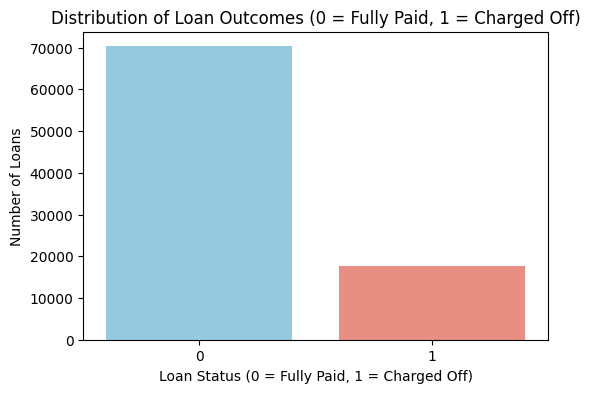

In [ ]:
# Visual check: target distribution plot

plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette=['skyblue','salmon'])
plt.title('Distribution of Loan Outcomes (0 = Fully Paid, 1 = Charged Off)')
plt.xlabel('Loan Status (0 = Fully Paid, 1 = Charged Off)')
plt.ylabel('Number of Loans')
plt.show()

In [ ]:
# === Re-create clean CSV properly (run after all cleaning & leak removal) ===
# This ensures clean_lendingclub_subset.csv has no leak columns and cleaned outliers.

# (Assumes df is already cleaned: dti replaced, revol_util clipped, annual_inc capped, leak_cols dropped)
# Double-check sentinel removal
df['dti'] = df['dti'].replace(999, np.nan)   # idempotent
# Drop any lingering leak columns
df = df.drop(columns=['loan_status_raw','loan_status_norm'], errors='ignore')

# Optional: ensure emp_length is string and treat missing consistently
df['emp_length'] = df['emp_length'].fillna('missing')

# Reset index and save
df.reset_index(drop=True, inplace=True)
df.to_csv("clean_lendingclub_subset.csv", index=False)
print("✔ Re-saved cleaned dataset (no leaks). Rows:", df.shape[0], "Cols:", df.shape[1])


✔ Re-saved cleaned dataset (no leaks). Rows: 87891 Cols: 23


In [ ]:
# Visualization setup
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load cleaned dataset from Day 1
df = pd.read_csv("clean_lendingclub_subset.csv")

print(" Cleaned dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Cleaned dataset loaded successfully!
Shape: (87891, 23)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,emp_length_years,emp_length_missing
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,0,debt_consolidation,5.91,0.0,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,10.0,0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,0,small_business,16.06,1.0,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,10.0,0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,0,home_improvement,10.78,0.0,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,10.0,0
3,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,0,major_purchase,25.37,1.0,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,3.0,0
4,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,0,debt_consolidation,10.20,0.0,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,4.0,0


In [ ]:
print("\n--- Dataset Overview ---")
df.info()

print("\n--- Statistical Summary (numerical features) ---")
display(df.describe().T.round(2))

print("\n--- Missing Values (Top 10 Columns) ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))


--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87891 entries, 0 to 87890
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_amnt           87891 non-null  float64
 1   term                87891 non-null  object 
 2   int_rate            87891 non-null  float64
 3   installment         87891 non-null  float64
 4   grade               87891 non-null  object 
 5   sub_grade           87891 non-null  object 
 6   emp_length          87891 non-null  object 
 7   home_ownership      87891 non-null  object 
 8   annual_inc          87891 non-null  float64
 9   loan_status         87891 non-null  int64  
 10  purpose             87891 non-null  object 
 11  dti                 87888 non-null  float64
 12  delinq_2yrs         87891 non-null  float64
 13  fico_range_low      87891 non-null  float64
 14  fico_range_high     87891 non-null  float64
 15  inq_last_6mths      87891 n

,count,mean,std,min,25%,50%,75%,max
loan_amnt,87891.0,14376.09,8595.70,1000.00,7900.00,12000.00,20000.00,35000.00
int_rate,87891.0,11.95,4.13,5.32,8.49,11.53,14.33,28.99
installment,87891.0,429.82,253.70,14.77,244.93,369.93,572.19,1354.66
annual_inc,87891.0,77685.20,89676.55,0.00,46000.00,65000.00,92624.00,9000000.00
loan_status,87891.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00
dti,87888.0,18.98,9.12,0.00,12.32,18.41,25.21,672.52
delinq_2yrs,87891.0,0.35,0.93,0.00,0.00,0.00,0.00,30.00
fico_range_low,87891.0,694.52,31.12,660.00,670.00,685.00,710.00,845.00
fico_range_high,87891.0,698.52,31.12,664.00,674.00,689.00,714.00,850.00
inq_last_6mths,87891.0,0.60,0.89,0.00,0.00,0.00,1.00,5.00



--- Missing Values (Top 10 Columns) ---
revol_util     36
dti             3
loan_amnt       0
installment     0
grade           0
term            0
int_rate        0
emp_length      0
sub_grade       0
loan_status     0
dtype: int64


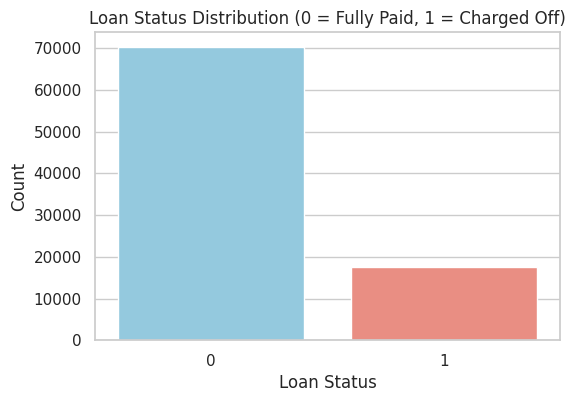

Proportion of Defaults: 20.03 %


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette=['skyblue','salmon'])
plt.title('Loan Status Distribution (0 = Fully Paid, 1 = Charged Off)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

print("Proportion of Defaults:", round(df['loan_status'].mean()*100, 2), "%")


###Numerical Features vs. Loan Status

####Interest Rate vs. Default

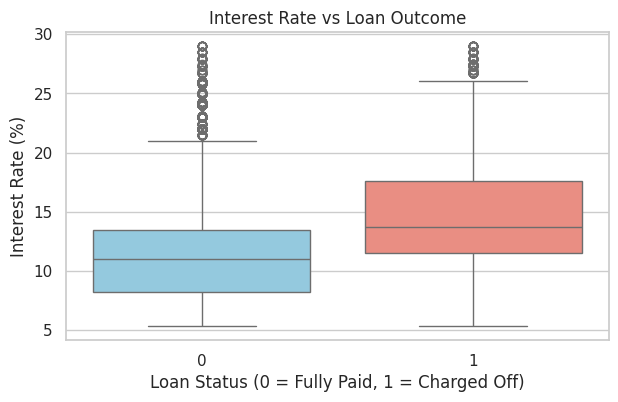

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x='loan_status', y='int_rate', data=df, palette=['skyblue','salmon'])
plt.title('Interest Rate vs Loan Outcome')
plt.xlabel('Loan Status (0 = Fully Paid, 1 = Charged Off)')
plt.ylabel('Interest Rate (%)')
plt.show()

####Annual Income vs. Default

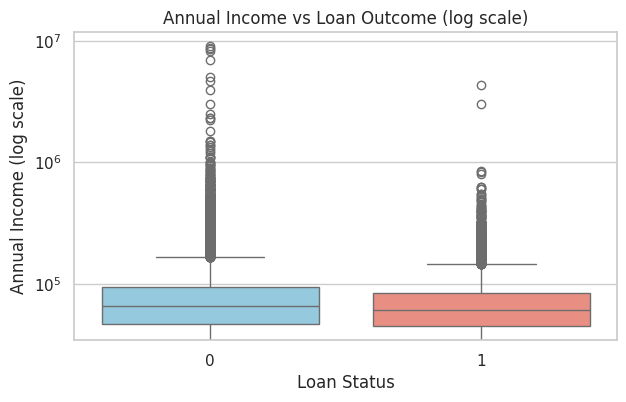

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x='loan_status', y='annual_inc', data=df, palette=['skyblue','salmon'])
plt.yscale('log')
plt.title('Annual Income vs Loan Outcome (log scale)')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income (log scale)')
plt.show()

####Loan Amount vs. Default

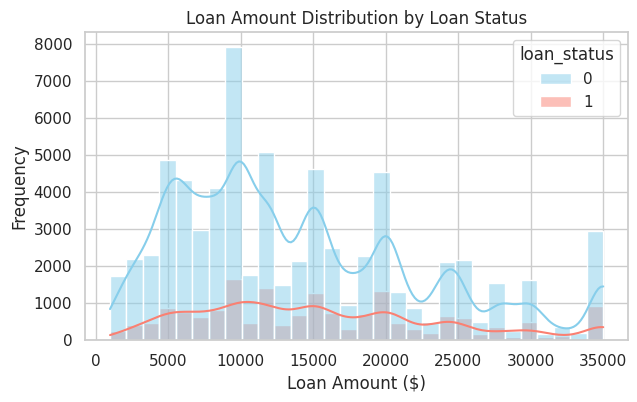

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='loan_amnt', hue='loan_status', kde=True, bins=30, palette=['skyblue','salmon'])
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Frequency')
plt.show()


####Debt-to-Income Ratio (DTI) vs. Default

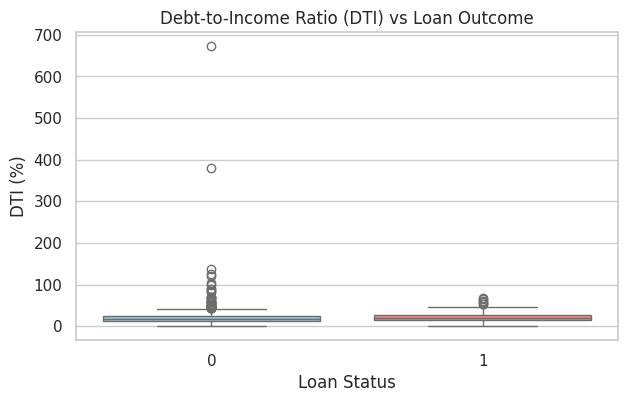

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x='loan_status', y='dti', data=df, palette=['skyblue','salmon'])
plt.title('Debt-to-Income Ratio (DTI) vs Loan Outcome')
plt.xlabel('Loan Status')
plt.ylabel('DTI (%)')
plt.show()


####Credit Quality: FICO Score Analysis

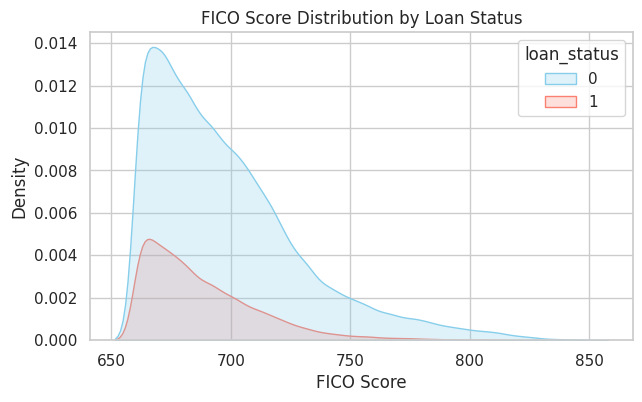

In [ ]:
df['fico_mean'] = (df['fico_range_low'] + df['fico_range_high']) / 2

plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x='fico_mean', hue='loan_status', fill=True, palette=['skyblue','salmon'])
plt.title('FICO Score Distribution by Loan Status')
plt.xlabel('FICO Score')
plt.ylabel('Density')
plt.show()


####Home Ownership vs. Default

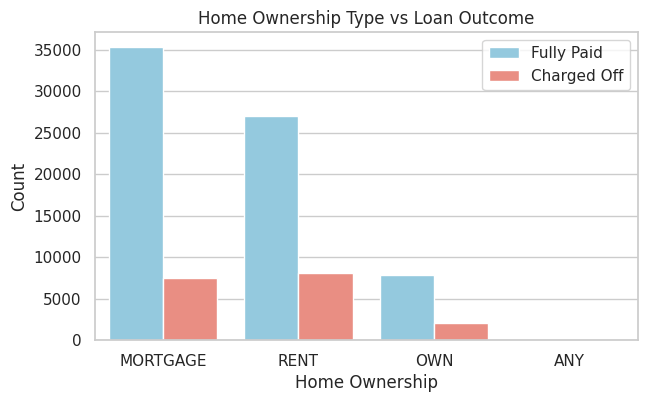

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='home_ownership', hue='loan_status', data=df, palette=['skyblue','salmon'])
plt.title('Home Ownership Type vs Loan Outcome')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.legend(['Fully Paid', 'Charged Off'])
plt.show()


####Loan Grade vs. Default

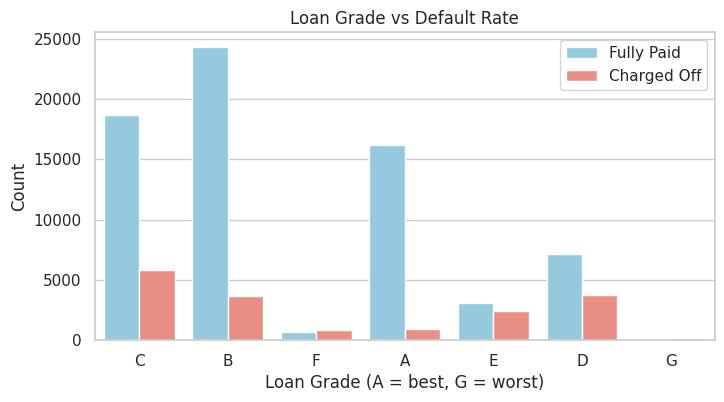

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='grade', hue='loan_status', data=df, palette=['skyblue','salmon'])
plt.title('Loan Grade vs Default Rate')
plt.xlabel('Loan Grade (A = best, G = worst)')
plt.ylabel('Count')
plt.legend(['Fully Paid', 'Charged Off'])
plt.show()


####Purpose of Loan vs. Default

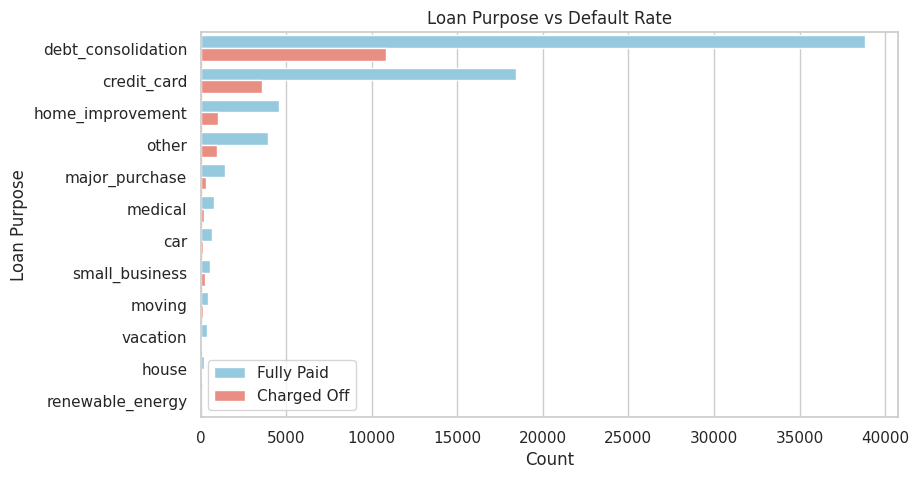

In [ ]:
plt.figure(figsize=(9,5))
sns.countplot(y='purpose', hue='loan_status', data=df, order=df['purpose'].value_counts().index, palette=['skyblue','salmon'])
plt.title('Loan Purpose vs Default Rate')
plt.xlabel('Count')
plt.ylabel('Loan Purpose')
plt.legend(['Fully Paid', 'Charged Off'])
plt.show()


####Correlation Matrix

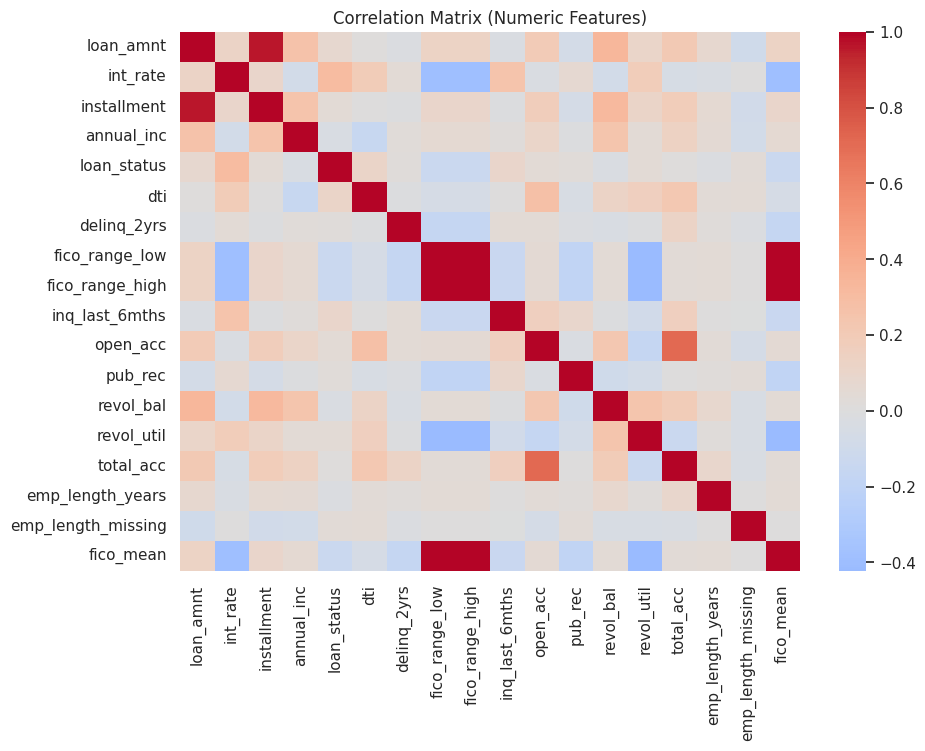

In [ ]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()


###Feature Engineering + Model Building

In [ ]:
# Feature Engineering & Model Building
# AI-Powered Financial Risk Scoring System


# Imports & settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

print("Libraries loaded.")


Libraries loaded.


In [ ]:
# Winsorize numeric columns at 1st/99th percentiles
num_to_cap = ['revol_bal','revol_util','pub_rec','annual_inc']
for c in num_to_cap:
    if c in df.columns:
        low = df[c].quantile(0.01)
        high = df[c].quantile(0.99)
        df[c] = df[c].clip(lower=low, upper=high)


In [ ]:
# 1) Load cleaned dataset created at the end of Day 1
df = pd.read_csv("clean_lendingclub_subset.csv")
print("Data shape:", df.shape)
display(df.head(3))

# 🚨 Data cleaning: treat sentinel/outliers before preprocessing
import numpy as np

# Mark known sentinel as missing
if 'dti' in df.columns:
    df['dti'] = df['dti'].replace(999, np.nan)

# Revolving utilization should be a percentage 0–100
if 'revol_util' in df.columns:
    df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')
    df.loc[df['revol_util'] > 100, 'revol_util'] = 100.0

# Cap extremely large annual incomes at 99th percentile
if 'annual_inc' in df.columns:
    df['annual_inc'] = pd.to_numeric(df['annual_inc'], errors='coerce')
    cap = df['annual_inc'].quantile(0.99)
    df.loc[df['annual_inc'] > cap, 'annual_inc'] = cap

# ✅ Remove target-leakage columns
leak_cols = ['loan_status_raw', 'loan_status_norm']
df = df.drop(columns=leak_cols, errors='ignore')
for c in leak_cols:
    assert c not in df.columns, f"Leak column still present: {c}"

print("✅ Cleaned dataset — no leakage, no sentinel values.")


# 🚨 Remove target leak columns
df = df.drop(columns=['loan_status_raw', 'loan_status_norm'], errors='ignore')
print("✅ Removed leakage columns (loan_status_raw, loan_status_norm)")
print("Remaining columns:", df.columns.tolist())

Data shape: (87891, 23)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,emp_length_years,emp_length_missing
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,0,debt_consolidation,5.91,0.0,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,10.0,0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,0,small_business,16.06,1.0,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,10.0,0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,0,home_improvement,10.78,0.0,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,10.0,0


✅ Cleaned dataset — no leakage, no sentinel values.
✅ Removed leakage columns (loan_status_raw, loan_status_norm)
Remaining columns: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'emp_length_years', 'emp_length_missing']


In [ ]:
# Quick guard checks
required = ['loan_status']
if not all([c in df.columns for c in required]):
    raise KeyError("Required column missing: 'loan_status'")

# Count class balance
print("Target distribution (counts):")
print(df['loan_status'].value_counts())
print("\nProportion of defaults (1):", round(df['loan_status'].mean(), 4))


Target distribution (counts):
loan_status
0    70288
1    17603
Name: count, dtype: int64

Proportion of defaults (1): 0.2003


In [ ]:
# ✅ Leak detection and removal (safety check)
leak_cols = ['loan_status_raw', 'loan_status_norm', 'loan_status_clean']  # add any that appear during cleaning
df = df.drop(columns=leak_cols, errors='ignore')

# Ensure no target-related leakage columns remain
for c in leak_cols:
    assert c not in df.columns, f"⚠️ Leak column still present: {c}"

print("✅ Leak check passed — no target-derived columns in df.")
# --- ✨ END INSERT ---

✅ Leak check passed — no target-derived columns in df.


In [ ]:
# Separate features and target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns (sample):", num_cols[:10])


Categorical columns: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'purpose']
Numerical columns (sample): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc']


In [ ]:
# Preprocessing pipeline:
# - Impute numeric with median
# - Encode categorical using OneHotEncoder (safe) and drop_first=False
# - Scale numeric features after imputation (StandardScaler)
# We'll use ColumnTransformer to combine steps.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')  # drop any other columns not specified


In [ ]:
# ---- Safe replace cell: ensure split, fit preprocessor once, build feature_names ----
import joblib
from sklearn.model_selection import train_test_split

# 0) Ensure X and y exist (derive from df if needed)
if 'X' not in globals() or 'y' not in globals():
    if 'df' not in globals():
        raise NameError("df not found. Load dataset into variable 'df' first.")
    X = df.drop(columns=['loan_status'], errors='ignore')
    y = df['loan_status']

# 1) Create train/test split only if not already present
if 'X_train_raw' not in globals() or 'X_test_raw' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    print("Created train/test split:")
else:
    print("Using existing X_train_raw / X_test_raw splits.")

print("X_train_raw.shape:", X_train_raw.shape, "X_test_raw.shape:", X_test_raw.shape)

# 2) Ensure preprocessor exists
if 'preprocessor' not in globals():
    raise NameError("preprocessor not found. Define your ColumnTransformer pipeline and name it 'preprocessor' before running this cell.")

# 3) Fit preprocessor on training data (fit only once)
preprocessor.fit(X_train_raw)
X_train_prep = preprocessor.transform(X_train_raw)
X_test_prep  = preprocessor.transform(X_test_raw)

# 4) Build feature_names robustly (derive num/cat cols if missing)
try:
    num_cols = X_train_raw.select_dtypes(include=[float,int]).columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include=['object','category']).columns.tolist()
except Exception:
    raise RuntimeError("Could not infer num_cols/cat_cols from X_train_raw.")

feature_names = list(num_cols)
if cat_cols:
    # find OHE safely
    ohe = None
    try:
        ohe = preprocessor.named_transformers_['cat'].named_steps.get('onehot', None)
    except Exception:
        try:
            cat_t = preprocessor.named_transformers_.get('cat')
            if cat_t is not None and hasattr(cat_t, 'named_steps') and 'onehot' in cat_t.named_steps:
                ohe = cat_t.named_steps['onehot']
        except Exception:
            ohe = None

    if ohe is not None:
        try:
            cat_names = ohe.get_feature_names_out(cat_cols).tolist()
        except Exception:
            try:
                cat_names = ohe.get_feature_names(cat_cols).tolist()
            except Exception:
                # fallback: synthesize using unique values
                cat_names = []
                for c in cat_cols:
                    vals = X_train_raw[c].astype(str).fillna('missing').unique().tolist()
                    for v in vals:
                        cat_names.append(f"{c}_{v}")
        feature_names += cat_names
    else:
        # fallback: guess number of categorical columns by shape
        n_cat_cols = X_train_prep.shape[1] - len(num_cols)
        feature_names += [f"cat_{i}" for i in range(n_cat_cols)]

# 5) Sanity checks and info
print("X_train_prep.shape:", X_train_prep.shape)
print("len(feature_names):", len(feature_names))
if X_train_prep.shape[1] != len(feature_names):
    print("⚠ WARNING: mismatch between preprocessed columns and feature_names length.")
    print("  X_train_prep.shape[1] =", X_train_prep.shape[1], "len(feature_names) =", len(feature_names))
    # do not auto-fix here; print extra/missing for debugging
    # show sample of feature_names and indices
    print("Sample feature_names (first 30):", feature_names[:30])
else:
    print("✅ Preprocessor fitted and feature_names built successfully.")

# 6) Save the fitted preprocessor for reproducibility
joblib.dump(preprocessor, "preprocessor.joblib")
print("Saved preprocessor -> preprocessor.joblib")


Created train/test split:
X_train_raw.shape: (70312, 22) X_test_raw.shape: (17579, 22)
X_train_prep.shape: (70312, 87)
len(feature_names): 87
✅ Preprocessor fitted and feature_names built successfully.
Saved preprocessor -> preprocessor.joblib


In [ ]:
# === Robust single cell: ensure splits exist, fit preprocessor on train, build feature_names ===
import joblib
from sklearn.model_selection import train_test_split
import numpy as np

# 0) Ensure X and y exist (derive from df if needed)
if 'X' not in globals() or 'y' not in globals():
    if 'df' not in globals():
        raise NameError("df not found. Load dataset into 'df' first.")
    X = df.drop(columns=['loan_status'], errors='ignore')
    y = df['loan_status']

# 1) If no train/test split exists, create train/test (80/20)
if 'X_train_raw' not in globals() or 'X_test_raw' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    print("Created X_train_raw / X_test_raw split.")
else:
    print("Using existing X_train_raw / X_test_raw.")

# 2) If validation split missing, create it by splitting X_train_raw (train-> 75%, val->25% of training)
if 'X_val_raw' not in globals() or 'y_val' not in globals():
    # create validation from X_train_raw
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_raw, y_train, test_size=0.25, stratify=y_train, random_state=42)
    print("Created X_val_raw from X_train_raw (train/val split).")
else:
    print("Using existing X_val_raw / y_val.")

print("Shapes -> X_train_raw:", X_train_raw.shape, "X_val_raw:", X_val_raw.shape, "X_test_raw:", X_test_raw.shape)

# 3) Ensure preprocessor exists
if 'preprocessor' not in globals():
    raise NameError("preprocessor not found. Define your ColumnTransformer pipeline named 'preprocessor' before running this cell.")

# 4) Fit preprocessor ONCE on train and transform val/test
preprocessor.fit(X_train_raw)
X_train_prep = preprocessor.transform(X_train_raw)
X_val_prep   = preprocessor.transform(X_val_raw)
X_test_prep  = preprocessor.transform(X_test_raw)
print("Preprocessor fitted and data transformed.")

# 5) Build feature_names robustly
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=['object','category']).columns.tolist()

feature_names = list(num_cols)
if cat_cols:
    # locate fitted OHE safely
    ohe = None
    try:
        ohe = preprocessor.named_transformers_['cat'].named_steps.get('onehot', None)
    except Exception:
        try:
            cat_t = preprocessor.named_transformers_.get('cat')
            if cat_t is not None and hasattr(cat_t, 'named_steps') and 'onehot' in cat_t.named_steps:
                ohe = cat_t.named_steps['onehot']
        except Exception:
            ohe = None

    if ohe is not None:
        try:
            cat_names = ohe.get_feature_names_out(cat_cols).tolist()
        except Exception:
            try:
                cat_names = ohe.get_feature_names(cat_cols).tolist()
            except Exception:
                # fallback: synthesize names from unique values
                cat_names = []
                for c in cat_cols:
                    vals = X_train_raw[c].astype(str).fillna('missing').unique().tolist()
                    for v in vals:
                        cat_names.append(f"{c}_{v}")
        feature_names += cat_names
    else:
        # fallback: estimate number of cat columns from transform shape
        n_cat_cols = X_train_prep.shape[1] - len(num_cols)
        feature_names += [f"cat_{i}" for i in range(n_cat_cols)]

# 6) Sanity checks & info
print("X_train_prep.shape:", X_train_prep.shape)
print("len(feature_names):", len(feature_names))
if X_train_prep.shape[1] != len(feature_names):
    print("⚠ WARNING: mismatch between preprocessed columns and feature_names length.")
    print("  X_train_prep.shape[1] =", X_train_prep.shape[1], "len(feature_names) =", len(feature_names))
    print("Sample feature_names (first 40):", feature_names[:40])
else:
    print("✅ Preprocessor fitted and feature_names built successfully.")

# 7) Save the preprocessor for reproducibility
joblib.dump(preprocessor, "preprocessor.joblib")
print("Saved preprocessor -> preprocessor.joblib")


Using existing X_train_raw / X_test_raw.
Created X_val_raw from X_train_raw (train/val split).
Shapes -> X_train_raw: (52734, 22) X_val_raw: (17578, 22) X_test_raw: (17579, 22)
Preprocessor fitted and data transformed.
X_train_prep.shape: (52734, 87)
len(feature_names): 87
✅ Preprocessor fitted and feature_names built successfully.
Saved preprocessor -> preprocessor.joblib


In [ ]:
# Handle class imbalance: Option A -> SMOTE (on training data only)
# Check for NaNs (should be none after pipeline)
import numpy as np
print("Any NaNs in X_train_prep?", np.isnan(X_train_prep).any())
print("Any NaNs in X_test_prep?", np.isnan(X_test_prep).any())

# Apply SMOTE (only on training set)
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_prep, y_train)

print("Before SMOTE class counts:", y_train.value_counts().to_dict())
print("After SMOTE class counts:", pd.Series(y_train_bal).value_counts().to_dict())
print("X_train_bal shape:", X_train_bal.shape)


Any NaNs in X_train_prep? False
Any NaNs in X_test_prep? False
Before SMOTE class counts: {0: 42172, 1: 10562}
After SMOTE class counts: {0: 42172, 1: 42172}
X_train_bal shape: (84344, 87)


### Model 1: Logistic Regression (baseline)

Logistic Regression - classification report (test):
              precision    recall  f1-score   support

           0       0.89      0.67      0.76     14058
           1       0.33      0.66      0.44      3521

    accuracy                           0.67     17579
   macro avg       0.61      0.67      0.60     17579
weighted avg       0.78      0.67      0.70     17579

ROC-AUC: 0.731830669136412


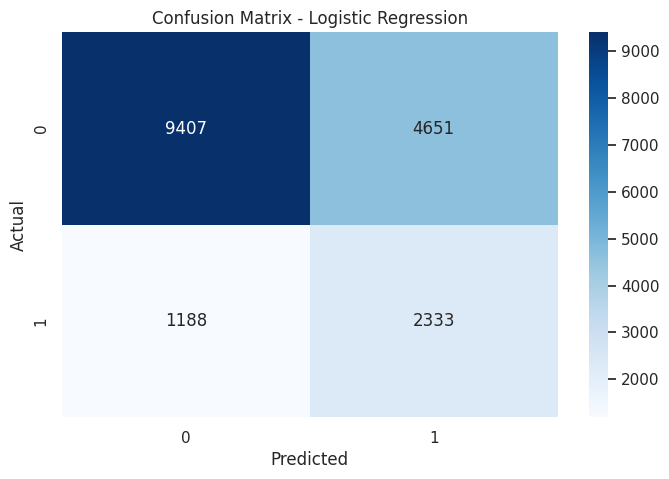

In [ ]:
log_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_clf.fit(X_train_bal, y_train_bal)  # trained on balanced data

# Predictions and probabilities on test set (original test set, not oversampled)
y_pred_log = log_clf.predict(X_test_prep)
y_prob_log = log_clf.predict_proba(X_test_prep)[:,1]

print("Logistic Regression - classification report (test):")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Random Forest

Random Forest - classification report (test):
              precision    recall  f1-score   support

           0       0.83      0.93      0.88     14058
           1       0.47      0.24      0.32      3521

    accuracy                           0.79     17579
   macro avg       0.65      0.59      0.60     17579
weighted avg       0.76      0.79      0.77     17579

ROC-AUC: 0.718359426595923


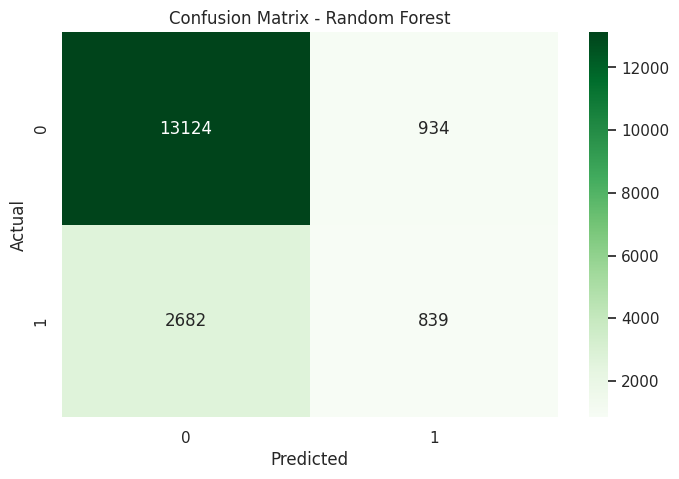

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_clf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf_clf.predict(X_test_prep)
y_prob_rf = rf_clf.predict_proba(X_test_prep)[:,1]

print("Random Forest - classification report (test):")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###XGBoost

XGBoost - classification report (test):
              precision    recall  f1-score   support

           0       0.87      0.72      0.79     14058
           1       0.35      0.59      0.43      3521

    accuracy                           0.70     17579
   macro avg       0.61      0.65      0.61     17579
weighted avg       0.77      0.70      0.72     17579

ROC-AUC: 0.7117816342398426


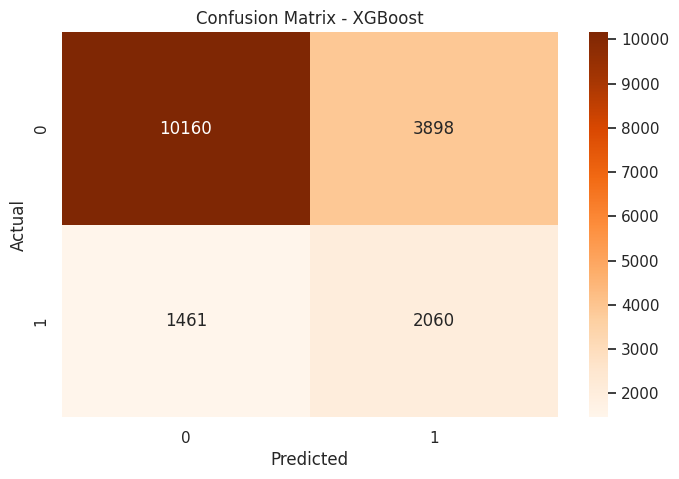

In [ ]:
# Use scale_pos_weight as alternative to SMOTE (but here we trained on SMOTE data; still okay to try)
# We'll set scale_pos_weight based on original y_train distribution
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=ratio)
# Train on original training data (not oversampled) to compare approach:
xgb_clf.fit(X_train_prep, y_train)

y_pred_xgb = xgb_clf.predict(X_test_prep)
y_prob_xgb = xgb_clf.predict_proba(X_test_prep)[:,1]

print("XGBoost - classification report (test):")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

####ROC curve **comparison**

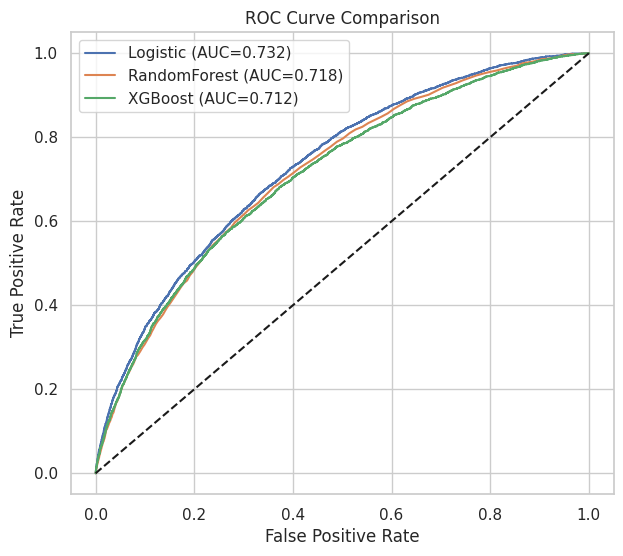

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC={roc_auc_score(y_test,y_prob_log):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC={roc_auc_score(y_test,y_prob_rf):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test,y_prob_xgb):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

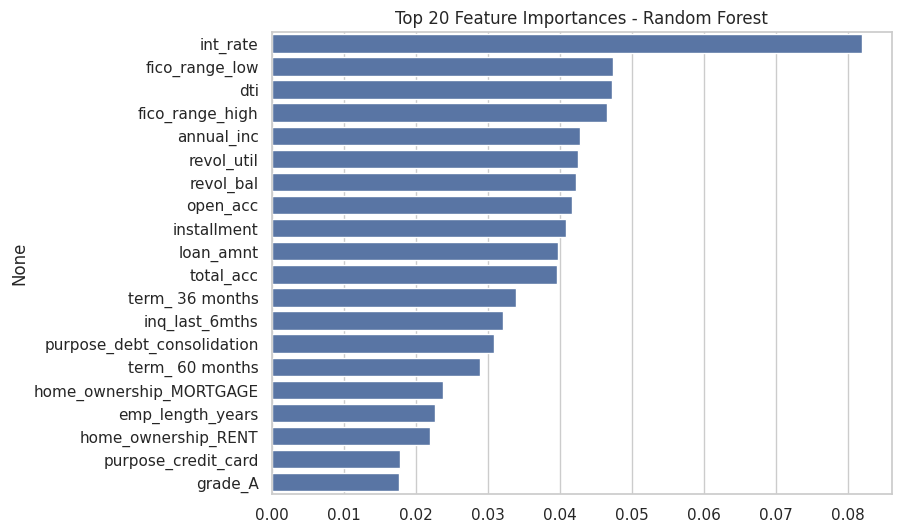

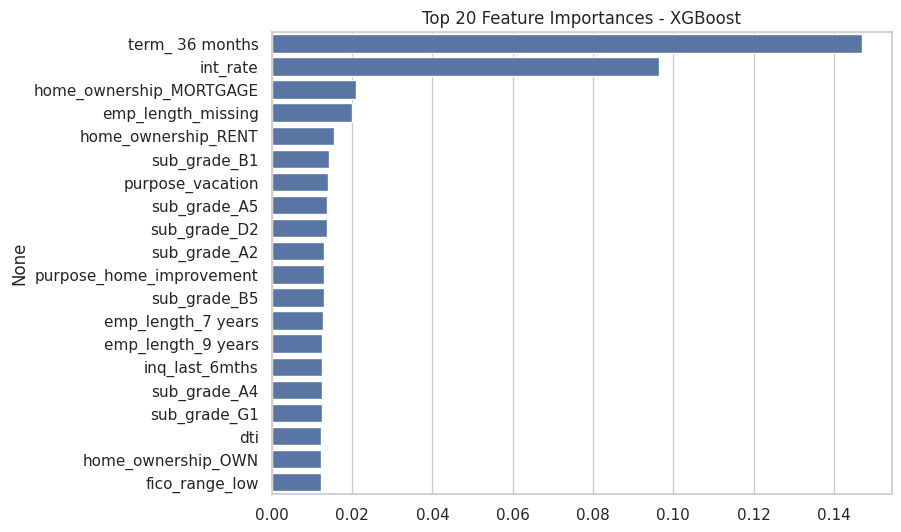

In [ ]:
# Feature importances: Random Forest + XGBoost (map back to feature names)
# Convert feature_names to length check
if len(feature_names) != X_train_prep.shape[1]:
    # In rare cases OneHotEncoder returns a different count; build names from transformers
    # We'll create a simple numeric index list instead
    feature_names = [f"f_{i}" for i in range(X_train_prep.shape[1])]

# Random Forest importances
rf_imp = pd.Series(rf_clf.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
sns.barplot(x=rf_imp.values, y=rf_imp.index)
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

# XGBoost importances
xgb_imp = pd.Series(xgb_clf.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
sns.barplot(x=xgb_imp.values, y=xgb_imp.index)
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix

y_prob = y_prob_log  # or whichever model you tune

prec, rec, thresh = precision_recall_curve(y_test, y_prob)

# 1) Threshold that maximizes F1 on test (be careful: ideally pick on validation CV, not test)
f1_scores = []
thresholds_f1 = thresh
for t in thresholds_f1:
    preds = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))
best_idx = np.argmax(f1_scores)
best_thresh_f1 = thresholds_f1[best_idx]
print(f"Threshold that maximizes F1: {best_thresh_f1:.4f}, F1={f1_scores[best_idx]:.3f}")

# 2) Option: choose threshold to satisfy a recall target but keep reasonable precision
target_recall = 0.75
chosen_threshold = None
for t, r in zip(thresh, rec[1:]):
    if r >= target_recall:
        chosen_threshold = t
        break
if chosen_threshold is None:
    chosen_threshold = 0.5
print("Threshold achieving recall>=%.2f (first): %0.4f" % (target_recall, chosen_threshold))

# Evaluate both
for name, t in [('F1-opt', best_thresh_f1), ('Recall-target', chosen_threshold)]:
    preds = (y_prob >= t).astype(int)
    print("\n==", name, "threshold", t)
    print(classification_report(y_test, preds))
    print("Confusion matrix:\n", confusion_matrix(y_test, preds))


Threshold that maximizes F1: 0.5365, F1=0.445
Threshold achieving recall>=0.75 (first): 0.0173

== F1-opt threshold 0.5365325226191328
              precision    recall  f1-score   support

           0       0.88      0.72      0.79     14058
           1       0.35      0.60      0.44      3521

    accuracy                           0.70     17579
   macro avg       0.62      0.66      0.62     17579
weighted avg       0.77      0.70      0.72     17579

Confusion matrix:
 [[10177  3881]
 [ 1403  2118]]

== Recall-target threshold 0.017315429547649308
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14058
           1       0.20      1.00      0.33      3521

    accuracy                           0.20     17579
   macro avg       0.10      0.50      0.17     17579
weighted avg       0.04      0.20      0.07     17579

Confusion matrix:
 [[    0 14058]
 [    0  3521]]


In [ ]:
# run this to see columns that may leak the target
print("Columns in dataframe:\n", df.columns.tolist())

# show a sample of the suspicious columns
for c in ['loan_status_raw','loan_status_norm']:
    if c in df.columns:
        print(f"\nSample values for {c}:")
        print(df[c].head(10).tolist())

Columns in dataframe:
 ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'emp_length_years', 'emp_length_missing']


In [ ]:
# Quick guard checks
required = ['loan_status']
if not all([c in df.columns for c in required]):
    raise KeyError("Required column missing: 'loan_status'")


In [ ]:
# Safe check+create X_explain + model info (copy-paste and run)
import numpy as np
import pandas as pd

# 0) Ensure preprocessed arrays and feature_names exist
if 'X_train_prep' not in globals() or 'X_test_prep' not in globals() or 'feature_names' not in globals():
    raise NameError("Ensure X_train_prep, X_test_prep and feature_names are available before running this cell.")

# 1) Build DataFrames from preprocessed arrays (so we can sample by index and keep names)
X_train_df = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_prep,  columns=feature_names)

# 2) Create X_explain if missing (positional sampling for reproducibility)
if 'X_explain' not in globals():
    sample_n = min(200, len(X_test_df))
    X_explain = X_test_df.sample(n=sample_n, random_state=42).reset_index(drop=True)
    print(f"Created X_explain from X_test_df: shape {X_explain.shape}")
else:
    # if X_explain exists but is array, ensure it's a DataFrame with columns
    if isinstance(X_explain, (np.ndarray, list)):
        X_explain = pd.DataFrame(np.asarray(X_explain), columns=feature_names[:np.asarray(X_explain).shape[1]])
        print("Converted existing X_explain array -> DataFrame.")
    else:
        print("Using existing X_explain.")

# 3) Choose a model to inspect if not already set
if 'model_to_explain' not in globals():
    model_to_explain = globals().get('xgb_clf', globals().get('rf_clf', globals().get('log_clf', None)))
    if model_to_explain is None:
        raise NameError("No model found in globals. Ensure xgb_clf / rf_clf / log_clf exist or set model_to_explain manually.")
    else:
        print("model_to_explain auto-selected:", [k for k in ['xgb_clf','rf_clf','log_clf'] if k in globals()][0])

# 4) Print shapes & expected feature count from model (if available)
print("\n--- Shapes ---")
print("X_train_prep.shape:", getattr(X_train_prep, "shape", None))
print("X_test_prep.shape: ", getattr(X_test_prep, "shape", None))
print("X_explain.shape:   ", getattr(X_explain, "shape", None))

print("\n--- Feature names ---")
print("len(feature_names) =", len(feature_names))
print("feature_names sample:", feature_names[:10])

# 5) Model expected feature count (best-effort)
expected = None
try:
    if hasattr(model_to_explain, "n_features_in_"):
        expected = int(model_to_explain.n_features_in_)
        print("\nModel attribute n_features_in_ found:", expected)
    else:
        # XGBoost booster fallback
        try:
            expected = int(model_to_explain.get_booster().num_features())
            print("\nModel booster reported num_features:", expected)
        except Exception:
            print("\nCould not read model expected feature count from model.")
except Exception as e:
    print("\nError reading model feature info:", e)

# 6) Compare and give guidance
if expected is not None:
    if expected == len(feature_names):
        print("\n✅ Model expects the same number of features as your preprocessor output.")
    else:
        print("\n⚠️ MISMATCH: Model expects", expected, "features but current feature_names length is", len(feature_names))
        # print last few feature names to help debug
        print("Last 6 feature_names:", feature_names[-6:])
        print("\nSuggested next steps (pick one):")
        print(" 1) If you trained the model with a different preprocessor, reload that preprocessor and use it for transform.")
        print("   -> joblib.load('preprocessor_that_trained_model.joblib') then transform your data with it.")
        print(" 2) If you want to use the current preprocessor, retrain the model on current preprocessed training data.")
        print(" 3) If the difference is only a few extra OHE columns (e.g., new categories), investigate which names are extra/missing and decide whether to drop or add them deliberately.")
        print("\nIf you want, I can show the exact extra/missing names now — tell me to 'show diffs' and I'll compute them.")
else:
    print("\nNo expected feature count available from model; ensure model was trained with feature names stored or retrain with this preprocessor.")


Created X_explain from X_test_df: shape (200, 87)

--- Shapes ---
X_train_prep.shape: (52734, 87)
X_test_prep.shape:  (17579, 87)
X_explain.shape:    (200, 87)

--- Feature names ---
len(feature_names) = 87
feature_names sample: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc']

Could not read model expected feature count from model.

No expected feature count available from model; ensure model was trained with feature names stored or retrain with this preprocessor.


In [ ]:
# 1) shapes
print("X_train_prep.shape:", getattr(X_train_prep, "shape", None))
print("X_test_prep.shape: ", getattr(X_test_prep, "shape", None))
print("X_explain.shape:   ", X_explain.shape)

# 2) model expected features
if hasattr(model_to_explain, "n_features_in_"):
    print("Model expects n_features_in_ =", model_to_explain.n_features_in_)
else:
    try:
        print("Model num_features:", model_to_explain.get_booster().num_features())
    except Exception:
        print("Cannot read model expected feature count")

# 3) feature_names length vs actual columns
print("len(feature_names) =", len(feature_names))
print("feature_names sample:", feature_names[:10])

X_train_prep.shape: (52734, 87)
X_test_prep.shape:  (17579, 87)
X_explain.shape:    (200, 87)
Cannot read model expected feature count
len(feature_names) = 87
feature_names sample: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc']


In [ ]:
# B - Simple feature-name sanity check (replace long alignment cell)
# Ensure the model(s) you trained expect the same number of features
from pprint import pprint

print("X_train_prep.shape:", X_train_prep.shape)
print("len(feature_names):", len(feature_names))
# Check a chosen trained model
for model_name, model in [('xgb_clf', globals().get('xgb_clf')), ('rf_clf', globals().get('rf_clf')), ('log_clf', globals().get('log_clf'))]:
    if model is None:
        continue
    expected = getattr(model, "n_features_in_", None)
    if expected is None:
        try:
            expected = int(model.get_booster().num_features())
        except Exception:
            expected = None
    print(f"{model_name} expects: {expected}")
    if expected is not None and expected != len(feature_names):
        print("⚠️ Feature count mismatch for", model_name)
        # don't auto-trim here — either retrain or load the preprocessor used to train the model


X_train_prep.shape: (52734, 87)
len(feature_names): 87
xgb_clf expects: 87
rf_clf expects: 87
log_clf expects: 87


In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np, pandas as pd

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
y_arr = np.asarray(y)  # full labels

fold_info = []
for i, (tr_idx, val_idx) in enumerate(cv.split(np.zeros(len(y_arr)), y_arr)):
    n_minority_train = (y_arr[tr_idx] == 1).sum()
    n_minority_val   = (y_arr[val_idx] == 1).sum()
    fold_info.append((i, len(tr_idx), n_minority_train, len(val_idx), n_minority_val))

pd.DataFrame(fold_info, columns=['fold','n_train','minority_train','n_val','minority_val'])


,fold,n_train,minority_train,n_val,minority_val
0,0,65918,13202,21973,4401
1,1,65918,13202,21973,4401
2,2,65918,13202,21973,4401
3,3,65919,13203,21972,4400


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import time

# --- Safe SMOTE and CV settings ---
sm = SMOTE(random_state=42, k_neighbors=3)  # lower k to be safe even on small subsets
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- Pipeline ---
pipe = ImbPipeline(steps=[
    ('preproc', preprocessor),
    ('smote', sm),
    ('clf', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=1,              # prevent oversubscription
        tree_method='hist'     # faster training
    ))
])

# --- Parameter space ---
param_dist = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.8, 1.0]
}

# --- Randomized Search ---
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=10,              # fewer iterations for faster run
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    verbose=2,
    random_state=42
)

t0 = time.time()
search.fit(X, y)
print("\n✅ Tuning complete in {:.1f} seconds".format(time.time() - t0))
print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

best_pipeline = search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END clf__learning_rate=0.1, clf__max_depth=7, clf__n_estimators=200, clf__subsample=1.0; total time=  27.0s
[CV] END clf__learning_rate=0.1, clf__max_depth=7, clf__n_estimators=200, clf__subsample=1.0; total time=  35.0s
[CV] END clf__learning_rate=0.1, clf__max_depth=7, clf__n_estimators=200, clf__subsample=1.0; total time=  19.2s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=100, clf__subsample=1.0; total time=   8.3s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=100, clf__subsample=1.0; total time=   7.9s
[CV] END clf__learning_rate=0.05, clf__max_depth=3, clf__n_estimators=100, clf__subsample=1.0; total time=   8.3s
[CV] END clf__learning_rate=0.1, clf__max_depth=3, clf__n_estimators=200, clf__subsample=0.8; total time=   9.3s
[CV] END clf__learning_rate=0.1, clf__max_depth=3, clf__n_estimators=200, clf__subsample=0.8; total time=  12.0s
[CV] END clf__learning_rate=0.1,

In [ ]:
# === Select best_model safely before threshold tuning ===
# Compare the models (based on ROC-AUC on validation set)

from sklearn.metrics import roc_auc_score

# Make sure these exist — remove ones you didn’t train
models = {
    "Logistic Regression": log_clf,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf
}

roc_scores = {}
for name, model in models.items():
    try:
        y_prob = model.predict_proba(X_val_prep)[:, 1]
        auc = roc_auc_score(y_val, y_prob)
        roc_scores[name] = auc
        print(f"{name}: ROC-AUC = {auc:.3f}")
    except Exception as e:
        print(f"{name} failed:", e)

best_model_name = max(roc_scores, key=roc_scores.get)
best_model = models[best_model_name]
print(f"\n✅ Best model selected: {best_model_name} (AUC = {roc_scores[best_model_name]:.3f})")


###Threshold tuning

#####Common business goal: increase recall for defaults (catch more risky loans) while keeping false positives manageable.

In [ ]:
# D - robust threshold selection (run on validation set, not test)
from sklearn.metrics import precision_recall_curve, classification_report

# choose model probabilities on validation
# Fit the best pipeline on the training data
best_pipeline.fit(X_train_raw, y_train)
# Transform the validation data using the fitted pipeline
X_val_prep_aligned = best_pipeline.named_steps['preproc'].transform(X_val_raw)
y_prob_val = best_pipeline.predict_proba(X_val_raw)[:,1]   # ensure best_model selected from validation
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)

target_recall = 0.70
min_precision = 0.20
chosen_threshold = None

# thresholds align with precisions[1:], recalls[1:]
for thr, prec, rec in zip(thresholds, precisions[1:], recalls[1:]):
    if rec >= target_recall and prec >= min_precision:
        chosen_threshold = thr
        break

# fallback: maximize F1 on validation
if chosen_threshold is None:
    pr = precisions[1:]; rr = recalls[1:]
    f1_scores = np.where((pr+rr)>0, 2*pr*rr/(pr+rr), 0)
    best_idx = int(np.nanargmax(f1_scores)) if f1_scores.size>0 else None
    chosen_threshold = thresholds[best_idx] if best_idx is not None else 0.5

print("Chosen threshold:", chosen_threshold)
print(classification_report(y_val, (y_prob_val >= chosen_threshold).astype(int)))

Chosen threshold: 0.0077724047
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14058
           1       0.20      1.00      0.33      3520

    accuracy                           0.20     17578
   macro avg       0.10      0.50      0.17     17578
weighted avg       0.04      0.20      0.07     17578



In [ ]:
# E - small helper to align arrays to model expectation before predict
def align_X_for_model(model, X_array, current_feature_names):
    # if model has feature_names_in_ use that to reorder/fill zeros
    try:
        model_cols = list(model.feature_names_in_)
    except Exception:
        try:
            model_cols = None
            booster = model.get_booster()
            model_cols = booster.feature_names if getattr(booster, 'feature_names', None) is not None else None
        except Exception:
            model_cols = None

    if model_cols is None:
        # fallback to count alignment: trim or pad zeros
        expected = getattr(model, 'n_features_in_', None)
        if expected is not None:
            if expected == X_array.shape[1]:
                return X_array
            elif expected < X_array.shape[1]:
                return X_array[:, :expected]
            else:
                pad = np.zeros((X_array.shape[0], expected - X_array.shape[1]))
                return np.hstack([X_array, pad])
        return X_array

    # build DF + align/order
    df_tmp = pd.DataFrame(X_array, columns=current_feature_names)
    for col in model_cols:
        if col not in df_tmp.columns:
            df_tmp[col] = 0.0
    aligned = df_tmp.reindex(columns=model_cols, fill_value=0.0).values
    return aligned

# Usage when evaluating:
X_for_log = align_X_for_model(log_clf, X_test_prep, feature_names)
y_prob_log = log_clf.predict_proba(X_for_log)[:,1]



--- Evaluating Logistic ---
              precision    recall  f1-score   support

           0       0.89      0.67      0.76     14058
           1       0.33      0.66      0.44      3521

    accuracy                           0.67     17579
   macro avg       0.61      0.67      0.60     17579
weighted avg       0.78      0.67      0.70     17579

ROC-AUC: 0.7318

--- Evaluating RandomForest ---
              precision    recall  f1-score   support

           0       0.83      0.93      0.88     14058
           1       0.47      0.24      0.32      3521

    accuracy                           0.79     17579
   macro avg       0.65      0.59      0.60     17579
weighted avg       0.76      0.79      0.77     17579

ROC-AUC: 0.7184

--- Evaluating XGBoost ---
              precision    recall  f1-score   support

           0       0.87      0.72      0.79     14058
           1       0.35      0.59      0.43      3521

    accuracy                           0.70     17579
   mac

,model,roc_auc,accuracy,precision,recall,f1
0,Logistic,0.731831,0.667842,0.334049,0.662596,0.444169
1,RandomForest,0.718359,0.793276,0.469075,0.243397,0.320494
2,XGBoost,0.711782,0.695148,0.345754,0.585061,0.434645


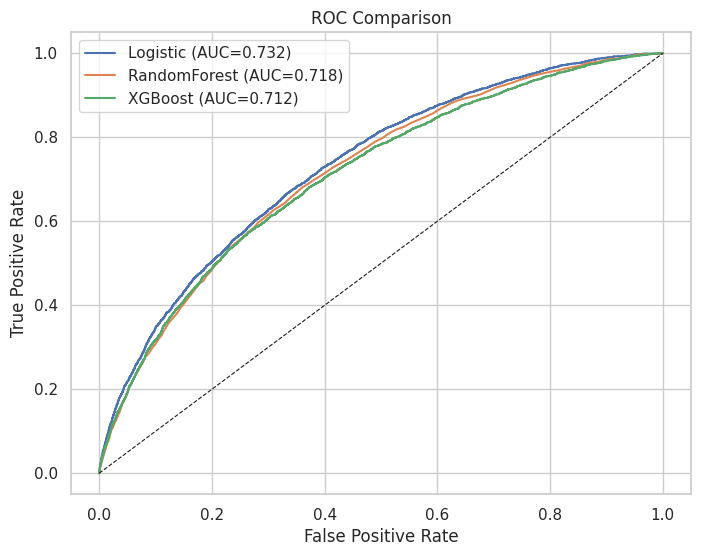

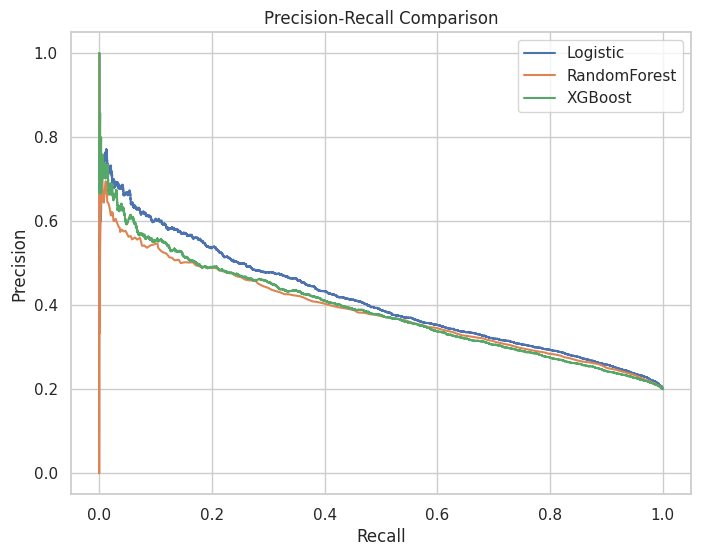

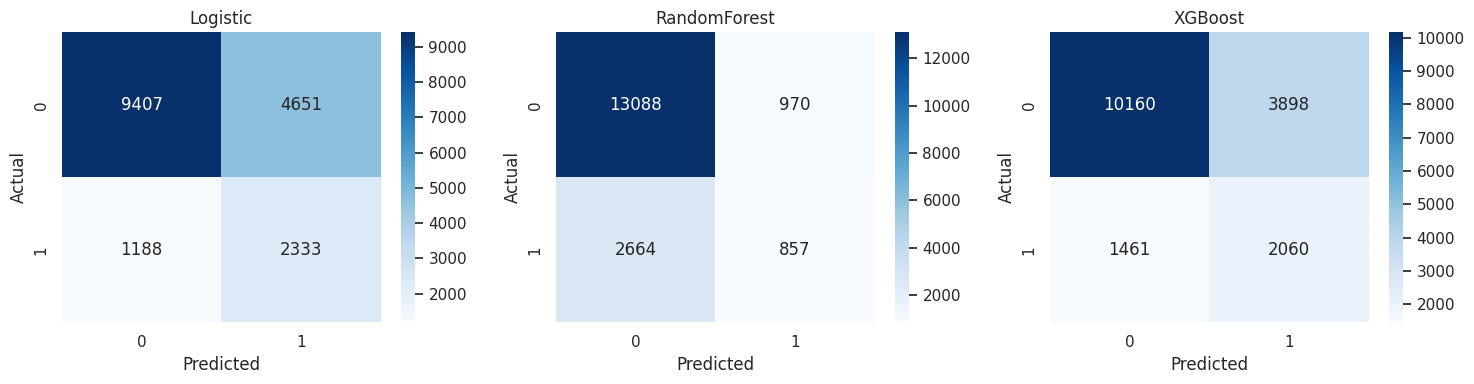


Best model by ROC-AUC: Logistic
Saved final pipeline to final_pipeline.joblib
Saved model comparison CSV: model_comparison_results.csv
Done.


In [ ]:
# === Final evaluation cell (run after align_X_for_model helper) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report
)
import joblib

sns.set(style="whitegrid")

# Ensure variables exist
assert 'feature_names' in globals(), "feature_names not found - run preprocessor cell first."
assert 'X_test_prep' in globals(), "X_test_prep not found - run preprocessing/transforms first."
assert 'y_test' in globals(), "y_test not found - run splits first."

models = {
    "Logistic": globals().get('log_clf'),
    "RandomForest": globals().get('rf_clf'),
    "XGBoost": globals().get('xgb_clf')
}

results = []
pred_probs = {}

# Evaluate each model (use align helper to avoid shape issues)
for name, model in models.items():
    if model is None:
        print(f"Skipping {name}: model not found.")
        continue
    print(f"\n--- Evaluating {name} ---")
    X_al = align_X_for_model(model, X_test_prep, feature_names)
    # predictions / probs
    try:
        y_prob = model.predict_proba(X_al)[:,1]
    except Exception:
        # fallback to decision_function scaled to [0,1]
        try:
            scores = model.decision_function(X_al)
            smin, smax = scores.min(), scores.max()
            y_prob = (scores - smin) / (smax - smin) if smax > smin else np.zeros_like(scores)
        except Exception:
            y_prob = model.predict(X_al).astype(float)

    y_pred = (y_prob >= 0.5).astype(int)  # default threshold 0.5 (you may replace with chosen_threshold)
    # metrics
    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(classification_report(y_test, y_pred, zero_division=0))
    print("ROC-AUC: {:.4f}".format(auc))

    results.append({
        "model": name,
        "roc_auc": auc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })
    pred_probs[name] = y_prob

# Summary table
results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df.style.background_gradient(cmap="Blues", axis=None))

# ROC Comparison plot
plt.figure(figsize=(8,6))
for name, probs in pred_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Comparison"); plt.legend(); plt.show()

# Precision-Recall Comparison
plt.figure(figsize=(8,6))
for name, probs in pred_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Comparison"); plt.legend(); plt.show()

# Confusion matrices (using default 0.5 threshold)
fig, axes = plt.subplots(1, len(pred_probs), figsize=(5*len(pred_probs),4))
if len(pred_probs)==1:
    axes = [axes]
for ax, (name, probs) in zip(axes, pred_probs.items()):
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

# Save results & choose final model
results_df.to_csv("model_comparison_results.csv", index=False)
best_name = results_df.loc[0, "model"]
print("\nBest model by ROC-AUC:", best_name)

# Save final pipeline: preprocessor + best model
best_model_obj = models.get(best_name)
final_pipeline = None
if best_model_obj is not None:
    # If you have a sklearn Pipeline class available, it is convenient to save that.
    from sklearn.pipeline import Pipeline as SkPipeline
    final_pipeline = SkPipeline(steps=[('preproc', preprocessor), ('model', best_model_obj)])
    joblib.dump(final_pipeline, "final_pipeline.joblib")
    print("Saved final pipeline to final_pipeline.joblib")

print("Saved model comparison CSV: model_comparison_results.csv")
print("Done.")


##Scorecard

####utilities: binning, WoE, IV, apply maps

In [ ]:
# === Cell A: WoE/IV utilities ===
import numpy as np, pandas as pd
from sklearn.utils import resample

def _safe_qcut(series, n_bins=10):
    """Try qcut, fallback to cut if duplicates present."""
    try:
        bins = pd.qcut(series, q=n_bins, duplicates='drop')
        # if qcut made fewer bins than requested, that's OK
        return bins
    except Exception:
        return pd.cut(series, bins=n_bins)

def compute_woe_iv(df, feature, target, bins=None, categorical=False, min_samples=0.01):
    """
    Compute WoE mapping and IV for a single feature.
    Returns: woe_map {bin_label: woe}, iv_value, bin_edges (for numeric)
    """
    s = df[feature]
    df2 = pd.DataFrame({'x': s, 'y': df[target]})
    if categorical:
        grp = df2.groupby('x', dropna=False)['y'].agg(['count','sum'])
        grp = grp.rename(columns={'sum':'events','count':'total'})
    else:
        # numeric binning via qcut with fallback
        bins_series = _safe_qcut(df2['x'], n_bins=(bins or 10))
        df2['bin'] = bins_series
        grp = df2.groupby('bin')['y'].agg(['count','sum'])
        grp = grp.rename(columns={'sum':'events','count':'total'})
    # ensure no-zero counts
    grp['non_events'] = grp['total'] - grp['events']
    # replace 0s with small value to avoid div-by-zero
    grp['events'] = grp['events'].replace(0, 0.5)
    grp['non_events'] = grp['non_events'].replace(0, 0.5)
    total_events = grp['events'].sum()
    total_non_events = grp['non_events'].sum()
    grp['dist_events'] = grp['events'] / total_events
    grp['dist_non_events'] = grp['non_events'] / total_non_events
    grp['woe'] = np.log(grp['dist_events'] / grp['dist_non_events'])
    grp['iv'] = (grp['dist_events'] - grp['dist_non_events']) * grp['woe']
    iv = grp['iv'].sum()
    # build mapping: for numeric bins use bin intervals, for cat use exact values
    if categorical:
        woe_map = grp['woe'].to_dict()
        bin_edges = None
    else:
        # mapping from interval (pd.Interval) to woe
        woe_map = {b: v for b, v in zip(grp.index.astype(str), grp['woe'].values)}
        bin_edges = grp.index.categories if hasattr(grp.index, 'categories') else None
    return woe_map, iv, bin_edges

def apply_woe_map_series(series, woe_map, numeric=True, default_woe=0.0):
    """Map a pandas Series to WoE using woe_map. For numeric: string bin labels are used."""
    if numeric:
        bins_series = _safe_qcut(series, n_bins=len(woe_map))  # best-effort
        # convert to string keys
        return bins_series.astype(str).map(lambda k: woe_map.get(k, default_woe))
    else:
        return series.map(lambda v: woe_map.get(v, default_woe))

def compute_iv_for_df(df, features, target, numeric_bins=10, min_iv=0.02):
    """
    Compute IV for multiple features. Returns DataFrame with iv values and woe maps dict.
    """
    iv_list = []
    woe_maps = {}
    for f in features:
        if df[f].dtype.kind in 'biufc':  # numeric-ish
            wmap, iv, edges = compute_woe_iv(df, f, target, bins=numeric_bins, categorical=False)
        else:
            wmap, iv, edges = compute_woe_iv(df, f, target, categorical=True)
        iv_list.append({'feature': f, 'iv': iv})
        woe_maps[f] = (wmap, edges)
    iv_df = pd.DataFrame(iv_list).sort_values('iv', ascending=False).reset_index(drop=True)
    return iv_df, woe_maps


####select candidate features and compute IV

In [ ]:
# === Cell B: compute IV on training data and choose good features ===
# choose candidate features from raw X (exclude identifiers)
candidate_features = [c for c in X_train_raw.columns if c not in ('id','member_id','issue_d')]
# optionally restrict to a manageable subset (uncomment if too many)
# candidate_features = candidate_features[:40]

iv_df, woe_maps = compute_iv_for_df(pd.concat([X_train_raw, y_train.rename('target')], axis=1),
                                    candidate_features, target='target', numeric_bins=10)

# show IV table
iv_df['iv_label'] = pd.cut(iv_df['iv'], bins=[-1,0.02,0.1,0.3,999], labels=['Useless','Weak','Medium','Strong'])
display(iv_df.head(50))
# pick features with IV >= 0.02 (weak or better)
selected_features = iv_df[iv_df['iv'] >= 0.02]['feature'].tolist()
print("Selected features (IV>=0.02):", selected_features)


,feature,iv,iv_label
0,sub_grade,0.660311,Strong
1,int_rate,0.638073,Strong
2,grade,0.605044,Strong
3,term,0.307361,Strong
4,fico_range_high,0.133231,Medium
5,fico_range_low,0.133231,Medium
6,dti,0.088631,Weak
7,loan_amnt,0.051865,Weak
8,installment,0.039476,Weak
9,inq_last_6mths,0.035814,Weak


Selected features (IV>=0.02): ['sub_grade', 'int_rate', 'grade', 'term', 'fico_range_high', 'fico_range_low', 'dti', 'loan_amnt', 'installment', 'inq_last_6mths', 'purpose', 'annual_inc', 'home_ownership']


####transform train/val/test to WoE features

In [ ]:
# === Cell C: build WoE-transformed datasets ===
def transform_df_to_woe(df_raw, woe_maps, selected_features):
    out = pd.DataFrame(index=df_raw.index)
    for f in selected_features:
        wmap, edges = woe_maps[f]
        if df_raw[f].dtype.kind in 'biufc':
            # numeric: bin by edges seen in train (we used string keys)
            s = df_raw[f]
            binned = _safe_qcut(s, n_bins=len(wmap))
            out[f] = binned.astype(str).map(lambda k: wmap.get(k, 0.0))
        else:
            out[f] = df_raw[f].map(lambda v: wmap.get(v, 0.0))
    return out

Xw_train = transform_df_to_woe(X_train_raw, woe_maps, selected_features)
Xw_val   = transform_df_to_woe(X_val_raw,   woe_maps, selected_features)
Xw_test  = transform_df_to_woe(X_test_raw,  woe_maps, selected_features)

print("WoE train shape:", Xw_train.shape)


WoE train shape: (52734, 13)


####train logistic on WoE, calibrate probabilities

In [ ]:
# === Cell D: logistic + calibration ===
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score

# simple logistic
log = LogisticRegression(max_iter=1000, solver='lbfgs')
log.fit(Xw_train, y_train)
print("Logistic trained. raw AUC (val):", roc_auc_score(y_val, log.predict_proba(Xw_val)[:,1]))

# calibrate using validation (Platt by default)
cal = CalibratedClassifierCV(log, cv='prefit', method='isotonic')  # or method='sigmoid'
cal.fit(Xw_val, y_val)  # calibrate on val
print("Calibrated. AUC (test):", roc_auc_score(y_test, cal.predict_proba(Xw_test)[:,1]))

# store for later
woe_log_model = log
woe_calibrated = cal


Logistic trained. raw AUC (val): 0.7303448113497328
Calibrated. AUC (test): 0.7262284876598992


####scorecard: convert log-odds to points

In [ ]:
# === Cell E: build scorecard mapping ===
import math

# Choose score scaling parameters (industry convention)
PDO = 20.0           # Points to Double Odds
base_odds = 1/50.0   # odds at base score (example: 1:50)
base_score = 600.0   # score corresponding to base_odds

factor = PDO / math.log(2)              # points per log2 odds
offset = base_score - factor * math.log(base_odds)

# compute contribution (points) per feature bin: points = offset_per_feature + factor * log(odds_bin)
# We will compute points for each feature bin using the trained logistic coef + intercept

# get logistic coefficients aligned to selected_features
coefs = pd.Series(woe_log_model.coef_.ravel(), index=selected_features)
intercept = float(woe_log_model.intercept_[0])

# For each feature, points = factor * (coef_f * woe_bin) + (offset * (coef_f*0?) we need a baseline)
# Simpler approach: convert each feature's WoE values into points by using average effect
# compute per-feature bin-average log-odds contribution and map to points

scorecard = {}
# baseline log-odds for an average borrower
avg_woe = Xw_train.mean()
base_log_odds = intercept + (coefs * avg_woe).sum()

for f in selected_features:
    # find unique bins present in training and compute avg woe per bin label
    wmap, _ = woe_maps[f]
    entries = []
    for bin_label, w in wmap.items():
        # contribution to log-odds for this bin:
        logodds_bin = intercept + (coefs * avg_woe).sum() - coefs[f]*avg_woe[f] + coefs[f]*w
        points = offset + factor * np.log(max(1e-9, np.exp(logodds_bin)))  # = offset + factor*logodds_bin
        entries.append({'bin': bin_label, 'woe': w, 'points': round(points,1)})
    scorecard[f] = pd.DataFrame(entries).sort_values('points', ascending=False).reset_index(drop=True)

# Print sample of scorecard for first 3 features
for f in selected_features[:3]:
    print("Feature:", f)
    display(scorecard[f].head(8))


Feature: sub_grade


,bin,woe,points
0,G4,3.058470,732.6
1,F5,2.122093,713.5
2,G3,2.003533,711.1
3,F3,1.800322,706.9
4,F4,1.500007,700.8
5,F2,1.495719,700.7
6,G1,1.449032,699.8
7,G5,1.384494,698.5


Feature: int_rate


,bin,woe,points
0,"(17.86, 28.99]",1.233508,667.0
1,"(15.41, 17.86]",0.811596,666.7
2,"(13.67, 15.41]",0.437294,666.4
3,"(12.59, 13.67]",0.286760,666.3
4,"(11.53, 12.59]",0.015754,666.1
5,"(10.64, 11.53]",-0.337907,665.8
6,"(9.17, 10.64]",-0.417448,665.7
7,"(8.18, 9.17]",-0.748680,665.4


Feature: grade


,bin,woe,points
0,A,-1.487777,667.7
1,B,-0.505856,666.3
2,C,0.212852,665.3
3,D,0.761261,664.5
4,E,1.130941,664.0
5,F,1.531547,663.4
6,G,1.654784,663.2


####Evaluate & plots (ROC, KS, calibration, score distribution)

Test AUC (calibrated): 0.7262284876598992


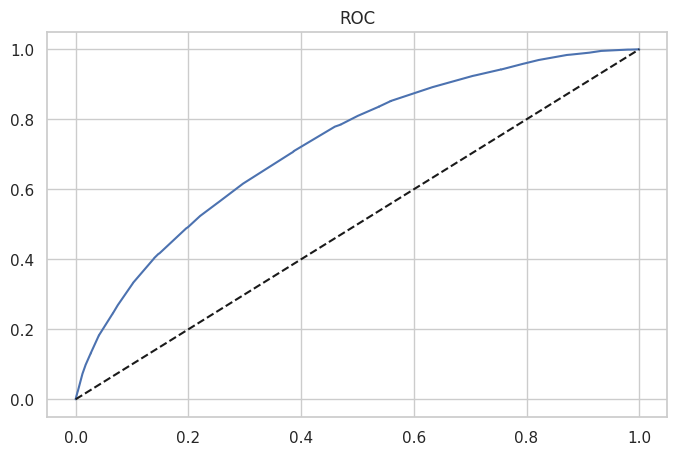

KS statistic: 0.3230353060386942


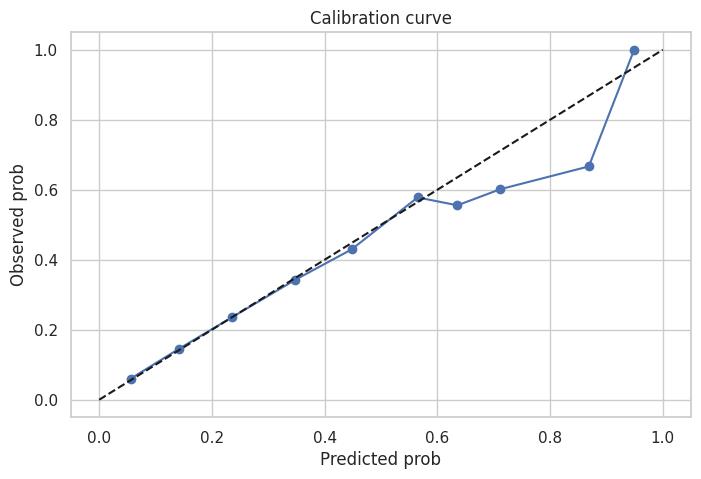

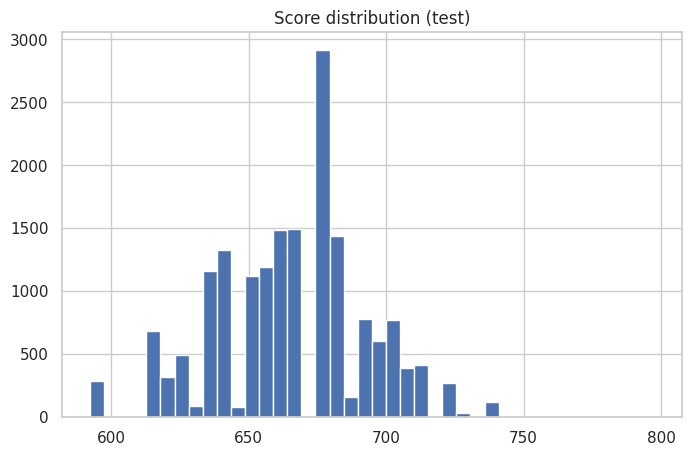

In [ ]:
# === Cell F: evaluation plots & KS ===
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probs
p_test = woe_calibrated.predict_proba(Xw_test)[:,1]
auc = roc_auc_score(y_test, p_test)
print("Test AUC (calibrated):", auc)

# ROC
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure(); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'k--'); plt.title("ROC"); plt.show()

# KS
# compute cumulative distributions
df_eval = pd.DataFrame({'prob': p_test, 'y': y_test})
df_eval = df_eval.sort_values('prob', ascending=False)
df_eval['cum_good'] = (1 - df_eval['y']).cumsum() / (1 - df_eval['y']).sum()
df_eval['cum_bad']  = df_eval['y'].cumsum() / df_eval['y'].sum()
ks = np.max(np.abs(df_eval['cum_bad'] - df_eval['cum_good']))
print("KS statistic:", ks)

# Calibration curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)
plt.figure(); plt.plot(prob_pred, prob_true, marker='o'); plt.plot([0,1],[0,1],'k--'); plt.title("Calibration curve"); plt.xlabel("Predicted prob"); plt.ylabel("Observed prob"); plt.show()

# Score distribution (map probs to score)
# Convert predicted probability to odds and then score: score = offset + factor*ln(odds)
odds = p_test / (1-p_test)
scores = offset + factor * np.log(np.maximum(odds, 1e-9))
plt.figure(); plt.hist(scores, bins=40); plt.title("Score distribution (test)"); plt.show()



Score -> Risk table (bands):


,band,count,defaults,default_rate,avg_pred_prob,avg_score,cum_pop_share,cum_default_share,cum_default_rate
0,775-799,1,1,1.000,0.949,797.3,0.000,0.000,1.000
1,750-774,3,2,0.667,0.869,767.6,0.000,0.001,0.750
2,725-749,145,86,0.593,0.698,737.1,0.008,0.025,0.597
3,700-724,1849,858,0.464,0.475,710.0,0.114,0.269,0.474
4,675-699,5875,1534,0.261,0.262,682.6,0.448,0.705,0.315
5,650-674,5282,772,0.146,0.142,660.7,0.748,0.924,0.247
6,625-649,3143,234,0.074,0.067,636.5,0.927,0.990,0.214
7,600-624,996,31,0.031,0.033,615.6,0.984,0.999,0.203
8,575-599,285,3,0.011,0.016,593.2,1.000,1.000,0.200



Saved score->risk table to: score_to_risk_table.csv


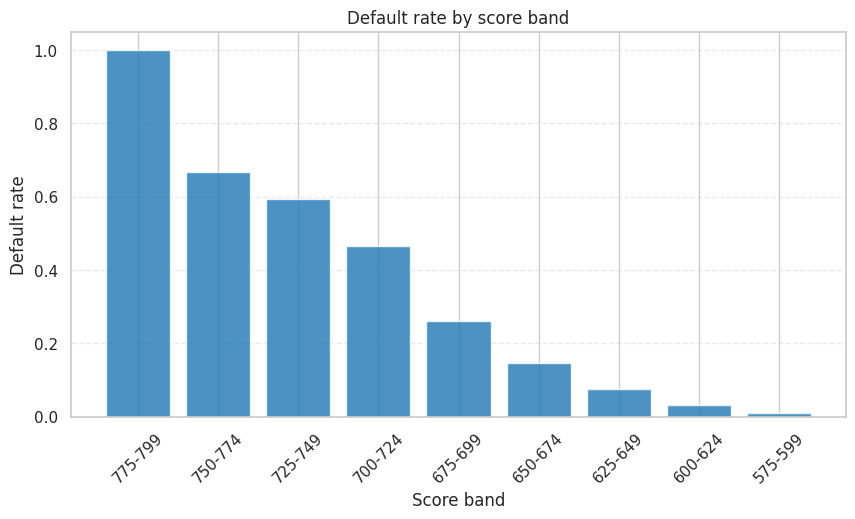


Top 3 (best scores) bands:


,band,count,default_rate
0,775-799,1,1.000000
1,750-774,3,0.666667
2,725-749,145,0.593103



Bottom 3 (worst scores) bands:


,band,count,default_rate
6,625-649,3143,0.074451
7,600-624,996,0.031124
8,575-599,285,0.010526


In [ ]:
# === Generate Score -> Risk table (score bands) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, math, os

# 1) Compute predicted probabilities and scores if not present
# If you already have 'p_test' and 'scores' from previous cells, they will be reused.
if 'p_test' not in globals():
    # try calibrated WoE model first, then fallback to final_model
    try:
        p_test = woe_calibrated.predict_proba(Xw_test)[:, 1]
    except Exception:
        try:
            p_test = final_model.predict_proba(X_test_prep)[:, 1]
        except Exception:
            raise RuntimeError("Cannot find p_test. Run calibration or ensure final model variables exist.")

# Score conversion: if 'scores' not present compute using offset & factor mapping used earlier.
if 'scores' not in globals():
    # require offset and factor from your scorecard cell; if not present compute basic log-odds -> score mapping
    if 'offset' in globals() and 'factor' in globals():
        # protect zeros in odds
        odds = np.maximum(p_test / (1 - p_test), 1e-9)
        scores = offset + factor * np.log(odds)
    else:
        # fallback: simple linear transform of predicted prob -> score (not ideal but usable)
        # map prob 0->800, prob 1->300 (reverse so higher score = lower risk)
        scores = 800 - (p_test * 500)
        print("⚠ Using fallback score mapping (linear). For proper mapping ensure 'offset' and 'factor' exist.")

# 2) Build DataFrame
df_scores = pd.DataFrame({
    'score': scores,
    'pred_prob': p_test,
    'y': y_test.values if hasattr(y_test, 'values') else np.array(y_test)
})

# 3) Choose bins (50-point bands by default). Adjust 'band_width' if you prefer 25, 100 etc.
band_width = 25  # change to 50 if you prefer wider bands
min_s = math.floor(df_scores['score'].min() / band_width) * band_width
max_s = math.ceil(df_scores['score'].max() / band_width) * band_width
bins = np.arange(min_s, max_s + band_width, band_width)
labels = [f"{int(b)}-{int(b+band_width-1)}" for b in bins[:-1]]

df_scores['band'] = pd.cut(df_scores['score'], bins=bins, labels=labels, include_lowest=True, right=False)

# 4) Aggregate metrics per band
agg = df_scores.groupby('band').agg(
    count = ('y','size'),
    defaults = ('y','sum'),
    avg_pred_prob = ('pred_prob','mean'),
    avg_score = ('score','mean')
).reset_index()

agg['default_rate'] = agg['defaults'] / agg['count']
agg = agg.sort_values('band', ascending=False).reset_index(drop=True)  # typically show high->low scores first

# Cumulative metrics (from best score -> worst)
agg['cum_count'] = agg['count'].cumsum()
agg['cum_defaults'] = agg['defaults'].cumsum()
total_count = agg['count'].sum()
total_defaults = agg['defaults'].sum()
agg['cum_pop_share'] = agg['cum_count'] / total_count
agg['cum_default_share'] = agg['cum_defaults'] / total_defaults
agg['cum_default_rate'] = agg['cum_defaults'] / agg['cum_count']

# 5) Clean-up for display
display_cols = ['band','count','defaults','default_rate','avg_pred_prob','avg_score','cum_pop_share','cum_default_share','cum_default_rate']
agg_display = agg[display_cols].copy()
agg_display['default_rate'] = agg_display['default_rate'].map("{:.3f}".format)
agg_display['avg_pred_prob'] = agg_display['avg_pred_prob'].map("{:.3f}".format)
agg_display['avg_score'] = agg_display['avg_score'].map("{:.1f}".format)
agg_display['cum_pop_share'] = agg_display['cum_pop_share'].map("{:.3f}".format)
agg_display['cum_default_share'] = agg_display['cum_default_share'].map("{:.3f}".format)
agg_display['cum_default_rate'] = agg_display['cum_default_rate'].map("{:.3f}".format)

print("\nScore -> Risk table (bands):")
display(agg_display)

# 6) Save to CSV
out_csv = "score_to_risk_table.csv"
agg.to_csv(out_csv, index=False)
print(f"\nSaved score->risk table to: {out_csv}")

# 7) Plot default_rate vs score band
plt.figure(figsize=(10,5))
plt.bar(agg['band'].astype(str), agg['default_rate'], color='tab:blue', alpha=0.8)
plt.xticks(rotation=45)
plt.xlabel("Score band")
plt.ylabel("Default rate")
plt.title("Default rate by score band")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 8) (Optional) Show top/bottom bands summary
print("\nTop 3 (best scores) bands:")
display(agg.head(3)[['band','count','default_rate']])
print("\nBottom 3 (worst scores) bands:")
display(agg.tail(3)[['band','count','default_rate']])


Saved per-band expected loss table to: score_band_expected_loss.csv

Per-band summary (top 20):


,band,count,defaults,default_rate,avg_pred_prob,avg_score,expected_defaults,expected_loss,expected_loss_per_account
8,775-799,1,1,1.000000,0.949104,797.295801,1.0,4500.0,4500.000000
7,750-774,3,2,0.666667,0.868703,767.632302,2.0,9000.0,3000.000000
6,725-749,145,86,0.593103,0.697758,737.117424,86.0,387000.0,2668.965517
5,700-724,1849,858,0.464035,0.475038,709.989290,858.0,3861000.0,2088.155760
4,675-699,5875,1534,0.261106,0.262332,682.596803,1534.0,6903000.0,1174.978723
3,650-674,5282,772,0.146157,0.142184,660.705979,772.0,3474000.0,657.705415
2,625-649,3143,234,0.074451,0.067111,636.534141,234.0,1053000.0,335.030226
1,600-624,996,31,0.031124,0.033355,615.600754,31.0,139500.0,140.060241
0,575-599,285,3,0.010526,0.015601,593.227891,3.0,13500.0,47.368421


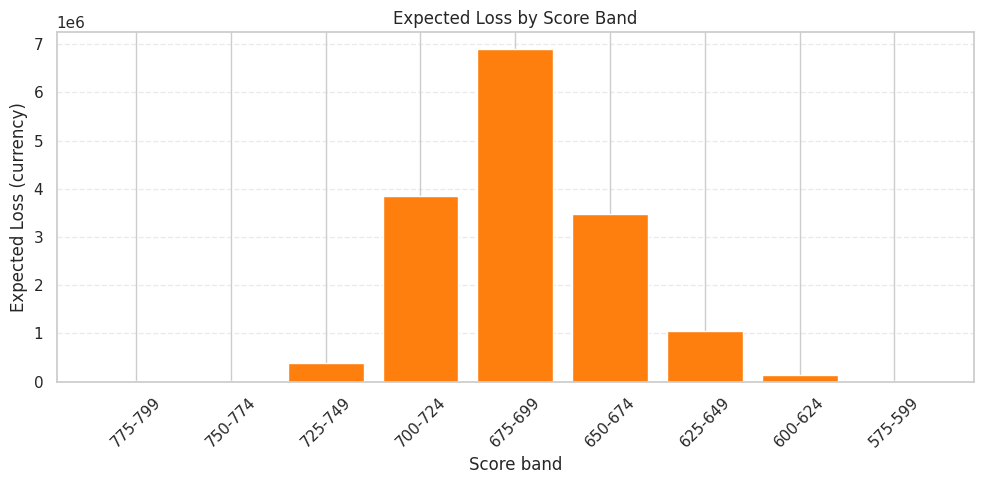


Operating targets: recall >= 0.70, precision >= 0.20
Selected cutoff (score <= thr => decline): 723.546  --  selection reason: no cutoff met both; chosen highest precision among those with recall>=target
Selected metrics: precision=0.197, recall=0.975, f1=0.328, decline_rate=0.992

Confusion matrix (rows=actual [0 good,1 bad], cols=predicted [0 accept,1 decline]):
[[   60 13998]
 [   89  3432]]

Classification report:
              precision    recall  f1-score   support

           0       0.40      0.00      0.01     14058
           1       0.20      0.97      0.33      3521

    accuracy                           0.20     17579
   macro avg       0.30      0.49      0.17     17579
weighted avg       0.36      0.20      0.07     17579


Saved cutoff search results to: score_cutoff_search_results.csv
Saved selected cutoff to selected_score_cutoff.txt


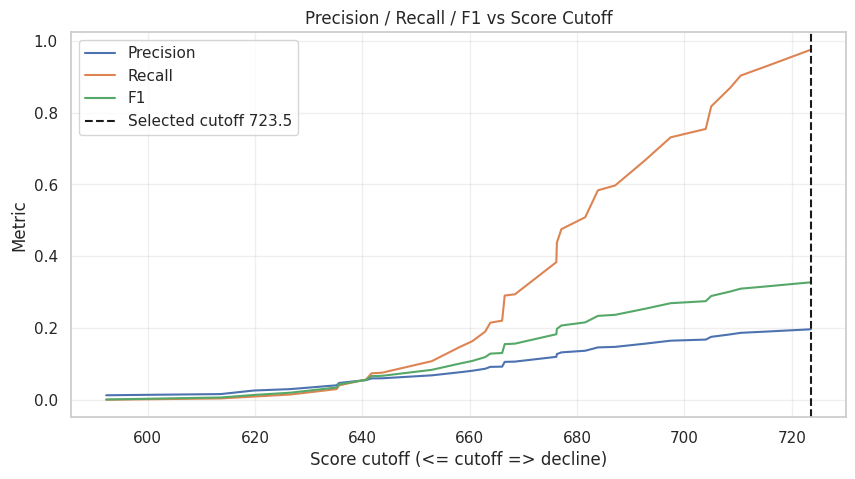


Top 5 bands by expected loss:


,band,count,defaults,default_rate,avg_pred_prob,avg_score,expected_defaults,expected_loss,expected_loss_per_account,expected_loss
4,675-699,5875,1534,0.261106,0.262332,682.596803,1534.0,6903000.0,1174.978723,6903000.0
5,700-724,1849,858,0.464035,0.475038,709.989290,858.0,3861000.0,2088.155760,3861000.0
3,650-674,5282,772,0.146157,0.142184,660.705979,772.0,3474000.0,657.705415,3474000.0
2,625-649,3143,234,0.074451,0.067111,636.534141,234.0,1053000.0,335.030226,1053000.0
6,725-749,145,86,0.593103,0.697758,737.117424,86.0,387000.0,2668.965517,387000.0



Bands with highest default rate:


,band,count,defaults,default_rate,avg_pred_prob,avg_score,expected_defaults,expected_loss,expected_loss_per_account,default_rate
8,775-799,1,1,1.000000,0.949104,797.295801,1.0,4500.0,4500.000000,1.000000
7,750-774,3,2,0.666667,0.868703,767.632302,2.0,9000.0,3000.000000,0.666667
6,725-749,145,86,0.593103,0.697758,737.117424,86.0,387000.0,2668.965517,0.593103
5,700-724,1849,858,0.464035,0.475038,709.989290,858.0,3861000.0,2088.155760,0.464035
4,675-699,5875,1534,0.261106,0.262332,682.596803,1534.0,6903000.0,1174.978723,0.261106



Done.


In [ ]:
# =========================
# Score-band expected loss + automatic cutoff search
# =========================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import math, os

sns.set(style="whitegrid")

# ---------- User inputs (change if needed) ----------
LGD = 0.45                # Loss Given Default (fraction), change if you have a domain value
avg_EAD = 10000.0         # Average exposure at default per borrower (currency units)
band_width = 25           # must match what you used before; used only if we need to rebuild bands
target_recall = 0.70      # example operating requirement
min_precision = 0.20      # example operating requirement
# ----------------------------------------------------

# --- 0) Ensure df_scores exists; otherwise build it from p_test and scores and y_test
if 'df_scores' not in globals():
    if 'p_test' not in globals() or 'scores' not in globals() or 'y_test' not in globals():
        raise RuntimeError("df_scores not found and cannot build it: ensure p_test, scores and y_test exist.")
    df_scores = pd.DataFrame({'score': scores, 'pred_prob': p_test, 'y': y_test.values if hasattr(y_test,'values') else np.array(y_test)})

# 1) Recompute bands if not present
if 'band' not in df_scores.columns:
    min_s = math.floor(df_scores['score'].min() / band_width) * band_width
    max_s = math.ceil(df_scores['score'].max() / band_width) * band_width
    bins = np.arange(min_s, max_s + band_width, band_width)
    labels = [f"{int(b)}-{int(b+band_width-1)}" for b in bins[:-1]]
    df_scores['band'] = pd.cut(df_scores['score'], bins=bins, labels=labels, include_lowest=True, right=False)

# 2) Ensure agg table
agg = df_scores.groupby('band').agg(
    count=('y','size'),
    defaults=('y','sum'),
    avg_pred_prob=('pred_prob','mean'),
    avg_score=('score','mean')
).reset_index().sort_values('band', ascending=False)

agg['default_rate'] = agg['defaults'] / agg['count']

# 3) Expected loss per band (EAD * LGD * expected defaults)
# expected_defaults = default_rate * count
agg['expected_defaults'] = agg['default_rate'] * agg['count']
agg['expected_loss'] = agg['expected_defaults'] * avg_EAD * LGD
agg['expected_loss_per_account'] = agg['expected_loss'] / agg['count']

# Save per-band table
out_band_csv = "score_band_expected_loss.csv"
agg.to_csv(out_band_csv, index=False)
print(f"Saved per-band expected loss table to: {out_band_csv}")

# display the table (top rows)
display_cols = ['band','count','defaults','default_rate','avg_pred_prob','avg_score','expected_defaults','expected_loss','expected_loss_per_account']
print("\nPer-band summary (top 20):")
display(agg[display_cols].head(20))

# 4) Plot expected loss by band
plt.figure(figsize=(10,5))
plt.bar(agg['band'].astype(str), agg['expected_loss'], color='tab:orange')
plt.xticks(rotation=45)
plt.xlabel("Score band")
plt.ylabel("Expected Loss (currency)")
plt.title("Expected Loss by Score Band")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5) Find score cutoff(s) for operating point
# We will evaluate candidate cutoffs from unique score percentiles (fast & robust).
scores_arr = df_scores['score'].values
y_arr = df_scores['y'].values

# Candidate cutoffs: use unique percentiles to avoid enormous loops
percentiles = np.linspace(1,99,99)   # 1..99 percentiles
candidates = np.unique(np.percentile(scores_arr, percentiles)).tolist()
# also include a few exact unique scores for safety
candidates += list(np.unique(scores_arr)[::max(1, len(scores_arr)//200)])
candidates = np.unique(candidates)
candidates = np.sort(candidates)

results = []
for thr in candidates:
    # define prediction: predict default (positive) if score <= thr (lower score = riskier)
    y_pred = (scores_arr <= thr).astype(int)
    prec = precision_score(y_arr, y_pred, zero_division=0)
    rec = recall_score(y_arr, y_pred, zero_division=0)
    f1 = f1_score(y_arr, y_pred, zero_division=0)
    dec_rate = y_pred.mean()  # fraction flagged/declined
    results.append({'cutoff': float(thr), 'precision': prec, 'recall': rec, 'f1': f1, 'decline_rate': dec_rate})

res_df = pd.DataFrame(results).sort_values(['recall','precision'], ascending=False).reset_index(drop=True)

# 6) Select best cutoff that satisfies both constraints (recall>=target_recall and precision>=min_precision)
candidate_ok = res_df[(res_df['recall'] >= target_recall) & (res_df['precision'] >= min_precision)]
selected = None
if len(candidate_ok) > 0:
    # choose cutoff that maximizes F1 among those (you can change selection logic)
    selected = candidate_ok.loc[candidate_ok['f1'].idxmax()]
    reason = "meets both constraints; selected by max F1"
else:
    # fallback strategy 1: find cutoffs with recall >= target_recall (maximize precision)
    cand1 = res_df[res_df['recall'] >= target_recall]
    if len(cand1) > 0:
        selected = cand1.loc[cand1['precision'].idxmax()]
        reason = "no cutoff met both; chosen highest precision among those with recall>=target"
    else:
        # fallback strategy 2: find cutoffs with precision >= min_precision (maximize recall)
        cand2 = res_df[res_df['precision'] >= min_precision]
        if len(cand2) > 0:
            selected = cand2.loc[cand2['recall'].idxmax()]
            reason = "no cutoff met recall target; chosen highest recall among those with precision>=min_precision"
        else:
            # final fallback: choose cutoff that maximizes F1 overall
            selected = res_df.loc[res_df['f1'].idxmax()]
            reason = "no cutoff met either constraint; chosen max F1 overall"

# 7) Show selection and details
print("\nOperating targets: recall >= {:.2f}, precision >= {:.2f}".format(target_recall, min_precision))
if selected is not None:
    thr = selected['cutoff']
    print("Selected cutoff (score <= thr => decline): {:.3f}  --  selection reason: {}".format(thr, reason))
    print("Selected metrics: precision={:.3f}, recall={:.3f}, f1={:.3f}, decline_rate={:.3f}".format(
        selected['precision'], selected['recall'], selected['f1'], selected['decline_rate']))
    # produce confusion matrix & classification report
    y_pred_sel = (scores_arr <= thr).astype(int)
    cm = confusion_matrix(y_arr, y_pred_sel)
    print("\nConfusion matrix (rows=actual [0 good,1 bad], cols=predicted [0 accept,1 decline]):")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_arr, y_pred_sel, zero_division=0))
else:
    print("No cutoff could be selected (unexpected).")

# 8) Save cutoff search results & selected cutoff
res_df.to_csv("score_cutoff_search_results.csv", index=False)
print("\nSaved cutoff search results to: score_cutoff_search_results.csv")

if selected is not None:
    with open("selected_score_cutoff.txt","w") as f:
        f.write(f"cutoff={selected['cutoff']}, precision={selected['precision']}, recall={selected['recall']}, f1={selected['f1']}\n")
    print("Saved selected cutoff to selected_score_cutoff.txt")

# 9) Visualize precision/recall vs cutoff (descending scores: lower cutoffs -> fewer declines)
plt.figure(figsize=(10,5))
plt.plot(res_df['cutoff'], res_df['precision'], label='Precision')
plt.plot(res_df['cutoff'], res_df['recall'], label='Recall')
plt.plot(res_df['cutoff'], res_df['f1'], label='F1')
plt.axvline(selected['cutoff'], color='k', linestyle='--', label=f"Selected cutoff {selected['cutoff']:.1f}")
plt.xlabel("Score cutoff (<= cutoff => decline)")
plt.ylabel("Metric")
plt.title("Precision / Recall / F1 vs Score Cutoff")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 10) Print top/bottom bands by expected loss for quick business insight
print("\nTop 5 bands by expected loss:")
display(agg.sort_values('expected_loss', ascending=False).head(5)[display_cols + ['expected_loss']])
print("\nBands with highest default rate:")
display(agg.sort_values('default_rate', ascending=False).head(5)[display_cols + ['default_rate']])

print("\nDone.")


Baseline: accounts=17579, defaults=3521, default_rate=0.2003, expected_loss=15,844,500.00

Selected cutoff: 723.546  (rule: highest_cutoff_meeting_constraints)
Selection reason: No cutoff met both; selected highest precision among those with recall>=target
Selected metrics: precision=0.197, recall=0.975, f1=0.328, decline_rate=0.992

Confusion matrix (rows=actual [0 good,1 bad], cols=predicted [0 accept,1 decline]):
[[   60 13998]
 [   89  3432]]

Classification report:
              precision    recall  f1-score   support

           0       0.40      0.00      0.01     14058
           1       0.20      0.97      0.33      3521

    accuracy                           0.20     17579
   macro avg       0.30      0.49      0.17     17579
weighted avg       0.36      0.20      0.07     17579


Portfolio summary after applying cutoff <= 723.5 => decline:
Accepted_count=149, Accepted_defaults=89
Rejected_count=17430, Rejected_defaults=3432
Baseline expected loss = 15,844,500.00
Expected lo

,cutoff,precision,recall,f1,decline_rate,accepted_count,accepted_defaults,expected_loss_after,expected_loss_reduction,baseline_expected_loss,baseline_default_rate
0,723.545768,0.196902,0.974723,0.327622,0.991524,149.0,89.0,400500.0,15444000.0,15844500.0,0.200296
1,704.993948,0.175931,0.817097,0.289524,0.930258,1226.0,644.0,2898000.0,12946500.0,15844500.0,0.200296
2,687.086991,0.147976,0.596989,0.237166,0.808066,3374.0,1419.0,6385500.0,9459000.0,15844500.0,0.200296
3,677.078239,0.132668,0.475433,0.207448,0.717788,4961.0,1847.0,8311500.0,7533000.0,15844500.0,0.200296
4,676.143492,0.120281,0.383698,0.183149,0.638944,6347.0,2170.0,9765000.0,6079500.0,15844500.0,0.200296
5,666.523136,0.106224,0.290826,0.155611,0.548382,7939.0,2497.0,11236500.0,4608000.0,15844500.0,0.200296
6,660.470387,0.081517,0.163590,0.108813,0.401957,10513.0,2945.0,13252500.0,2592000.0,15844500.0,0.200296
7,652.933096,0.068760,0.108208,0.084087,0.315206,12038.0,3140.0,14130000.0,1714500.0,15844500.0,0.200296
8,640.691287,0.055464,0.057086,0.056263,0.206155,13955.0,3320.0,14940000.0,904500.0,15844500.0,0.200296
9,626.554209,0.030423,0.015337,0.020393,0.100973,15804.0,3467.0,15601500.0,243000.0,15844500.0,0.200296


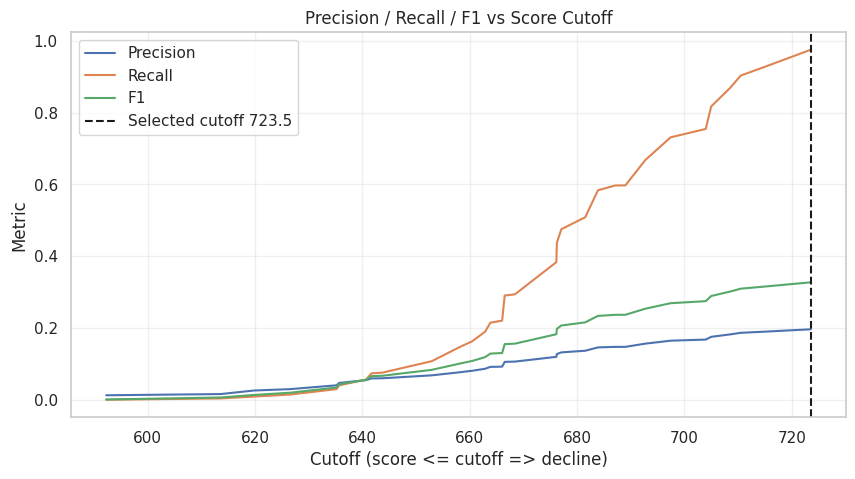

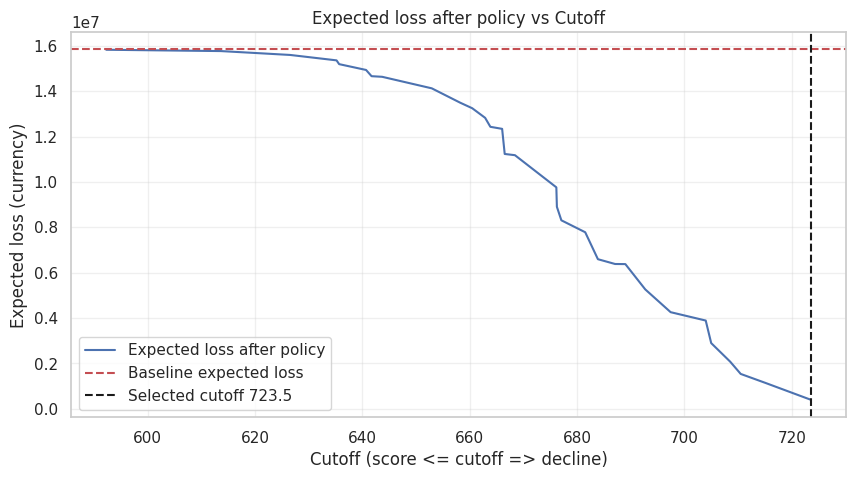


Done. Files saved: scorecut_kpi_table.csv


In [ ]:
# =============================
# Advanced cutoff selection + portfolio impact + KPI table
# =============================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, math, os
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
sns.set(style="whitegrid")

# ---------- User inputs (change if needed) ----------
LGD = 0.45                # Loss Given Default (fraction)
avg_EAD = 10000.0         # Average Exposure At Default (currency)
band_width = 25           # should match previous
target_recall = 0.70
min_precision = 0.20
selection_rule = "highest_cutoff_meeting_constraints"
# options: "max_f1", "best_precision_given_recall", "highest_cutoff_meeting_constraints"
# ---------------------------------------------------

# --- 0) Build df_scores if missing
if 'df_scores' not in globals():
    if not all(v in globals() for v in ['p_test','scores','y_test']):
        raise RuntimeError("df_scores not found and cannot be built: ensure p_test, scores, and y_test exist.")
    df_scores = pd.DataFrame({
        'score': np.asarray(scores),
        'pred_prob': np.asarray(p_test),
        'y': np.asarray(y_test) if hasattr(y_test, 'values')==False else y_test.values
    })

# ensure numeric arrays
scores_arr = np.asarray(df_scores['score'])
y_arr = np.asarray(df_scores['y'])
p_arr = np.asarray(df_scores['pred_prob'])

# baseline portfolio-level observed metrics (on test)
total_accounts = len(df_scores)
total_defaults = int(y_arr.sum())
baseline_default_rate = total_defaults / total_accounts
baseline_expected_loss = total_defaults * avg_EAD * LGD

print(f"Baseline: accounts={total_accounts}, defaults={total_defaults}, default_rate={baseline_default_rate:.4f}, expected_loss={baseline_expected_loss:,.2f}")

# --- 1) Build candidate cutoffs (unique percentiles + a sample of unique scores)
percentiles = np.linspace(1,99,99)
candidates = np.unique(np.percentile(scores_arr, percentiles)).tolist()
candidates += list(np.unique(scores_arr)[::max(1, len(scores_arr)//300)])
candidates = np.unique(candidates)
candidates = np.sort(candidates)

# --- 2) Evaluate metrics for each candidate cutoff
rows = []
for thr in candidates:
    # decline if score <= thr (lower score == riskier)
    y_pred = (scores_arr <= thr).astype(int)
    prec = precision_score(y_arr, y_pred, zero_division=0)
    rec = recall_score(y_arr, y_pred, zero_division=0)
    f1 = f1_score(y_arr, y_pred, zero_division=0)
    decline_rate = y_pred.mean()
    accept_rate = 1.0 - decline_rate

    # observed defaults in accepted set
    accepted_mask = (scores_arr > thr)
    accepted_count = accepted_mask.sum()
    accepted_defaults = int(y_arr[accepted_mask].sum()) if accepted_count>0 else 0

    # expected loss accepted = observed defaults in accepted * EAD * LGD
    expected_loss_accepted = accepted_defaults * avg_EAD * LGD
    # expected loss after policy = expected_loss_accepted
    expected_loss_after = expected_loss_accepted
    expected_loss_reduction = baseline_expected_loss - expected_loss_after

    rows.append({
        'cutoff': float(thr),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'decline_rate': float(decline_rate),
        'accept_rate': float(accept_rate),
        'accepted_count': int(accepted_count),
        'accepted_defaults': int(accepted_defaults),
        'expected_loss_after': float(expected_loss_after),
        'expected_loss_reduction': float(expected_loss_reduction)
    })

res_df = pd.DataFrame(rows).sort_values('cutoff')  # increasing cutoffs -> generally fewer declines

# --- 3) Selection logic based on rule
selected = None
reason = None

if selection_rule == "max_f1":
    idx = res_df['f1'].idxmax()
    selected = res_df.loc[idx]
    reason = "Max F1 across candidates"
elif selection_rule == "best_precision_given_recall":
    cand = res_df[res_df['recall'] >= target_recall]
    if len(cand)>0:
        idx = cand['precision'].idxmax()
        selected = res_df.loc[idx]
        reason = "Max precision among cutoffs with recall >= target"
    else:
        # fallback to max F1
        idx = res_df['f1'].idxmax()
        selected = res_df.loc[idx]
        reason = "No candidate met recall target; fallback to max F1"
elif selection_rule == "highest_cutoff_meeting_constraints":
    # conservative: choose HIGHEST cutoff (largest score) that still meets BOTH constraints
    cand = res_df[(res_df['recall'] >= target_recall) & (res_df['precision'] >= min_precision)]
    if len(cand)>0:
        idx = cand['cutoff'].idxmax()
        selected = res_df.loc[idx]
        reason = "Highest cutoff meeting both recall & precision constraints (conservative declines)"
    else:
        # fallback strategies
        cand1 = res_df[res_df['recall'] >= target_recall]
        if len(cand1)>0:
            idx = cand1['precision'].idxmax()
            selected = res_df.loc[idx]
            reason = "No cutoff met both; selected highest precision among those with recall>=target"
        else:
            idx = res_df['f1'].idxmax()
            selected = res_df.loc[idx]
            reason = "No cutoff met constraints; fallback to max F1"

# --- 4) Output selected cutoff & simulate portfolio impact
if selected is None:
    raise RuntimeError("No cutoff selected (unexpected).")
thr = selected['cutoff']
print(f"\nSelected cutoff: {thr:.3f}  (rule: {selection_rule})")
print(f"Selection reason: {reason}")
print(f"Selected metrics: precision={selected['precision']:.3f}, recall={selected['recall']:.3f}, f1={selected['f1']:.3f}, decline_rate={selected['decline_rate']:.3f}")

# Confusion matrix using selected cutoff (decline = predicted positive)
y_pred_sel = (scores_arr <= thr).astype(int)
cm = confusion_matrix(y_arr, y_pred_sel)
print("\nConfusion matrix (rows=actual [0 good,1 bad], cols=predicted [0 accept,1 decline]):")
print(cm)
print("\nClassification report:")
print(classification_report(y_arr, y_pred_sel, zero_division=0))

# Portfolio impact calculations
accepted_mask = (scores_arr > thr)
accepted_count = accepted_mask.sum()
accepted_defaults = int(y_arr[accepted_mask].sum())
rejected_count = total_accounts - accepted_count
rejected_defaults = total_defaults - accepted_defaults

baseline_EL = baseline_expected_loss
EL_after = accepted_defaults * avg_EAD * LGD
delta_EL = baseline_EL - EL_after

print(f"\nPortfolio summary after applying cutoff <= {thr:.1f} => decline:")
print(f"Accepted_count={accepted_count}, Accepted_defaults={accepted_defaults}")
print(f"Rejected_count={rejected_count}, Rejected_defaults={rejected_defaults}")
print(f"Baseline expected loss = {baseline_EL:,.2f}")
print(f"Expected loss after policy   = {EL_after:,.2f}")
print(f"Expected loss reduction (absolute) = {delta_EL:,.2f}")
if baseline_EL>0:
    print(f"Expected loss reduction (relative) = {100*delta_EL/baseline_EL:.2f}%")

# --- 5) KPI table for management (choose a few representative cutoffs to show)
# We'll pick a set of representative cutoffs: deciles + selected + baseline percentiles
rep_percentiles = list(range(10, 100, 10))
rep_cutoffs = list(np.unique(np.percentile(scores_arr, rep_percentiles)))
rep_cutoffs = sorted(set(rep_cutoffs + [thr]))

kpis = []
for cut in rep_cutoffs:
    row = res_df[res_df['cutoff']==cut].iloc[0] if cut in res_df['cutoff'].values else None
    if row is None:
        # find nearest candidate
        idx = (np.abs(res_df['cutoff'] - cut)).idxmin()
        row = res_df.loc[idx]
    kpis.append({
        'cutoff': row['cutoff'],
        'precision': row['precision'],
        'recall': row['recall'],
        'f1': row['f1'],
        'decline_rate': row['decline_rate'],
        'accepted_count': row['accepted_count'],
        'accepted_defaults': row['accepted_defaults'],
        'expected_loss_after': row['expected_loss_after'],
        'expected_loss_reduction': row['expected_loss_reduction']
    })

kpi_df = pd.DataFrame(kpis).sort_values('cutoff', ascending=False).reset_index(drop=True)
# add baseline columns
kpi_df['baseline_expected_loss'] = baseline_expected_loss
kpi_df['baseline_default_rate'] = baseline_default_rate

# Save KPI table
kpi_csv = "scorecut_kpi_table.csv"
kpi_df.to_csv(kpi_csv, index=False)
print(f"\nSaved KPI table to: {kpi_csv}")

# Display KPI table
print("\nRepresentative KPI table (higher score => safer, displayed high->low):")
display(kpi_df.head(20))

# --- 6) Plots: precision/recall vs cutoff & expected loss before/after
plt.figure(figsize=(10,5))
plt.plot(res_df['cutoff'], res_df['precision'], label='Precision')
plt.plot(res_df['cutoff'], res_df['recall'], label='Recall')
plt.plot(res_df['cutoff'], res_df['f1'], label='F1')
plt.axvline(thr, color='k', linestyle='--', label=f"Selected cutoff {thr:.1f}")
plt.xlabel("Cutoff (score <= cutoff => decline)")
plt.ylabel("Metric")
plt.title("Precision / Recall / F1 vs Score Cutoff")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(res_df['cutoff'], res_df['expected_loss_after'], label='Expected loss after policy')
plt.axhline(baseline_expected_loss, color='r', linestyle='--', label='Baseline expected loss')
plt.axvline(thr, color='k', linestyle='--', label=f"Selected cutoff {thr:.1f}")
plt.xlabel("Cutoff (score <= cutoff => decline)")
plt.ylabel("Expected loss (currency)")
plt.title("Expected loss after policy vs Cutoff")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nDone. Files saved:", kpi_csv)


Baseline: accounts=17579, observed_defaults=3521, observed_EL=15,844,500.00, model_based_EL=15,857,499.04

Selected cutoff: 723.546  (rule: highest_cutoff_meeting_constraints)  -- reason: no both; pick highest precision with recall>=target
Precision, Recall, F1 on test for selected cutoff:
Precision: 0.19690189328743546
Recall: 0.9747230900312411
F1: 0.32762159324137274

Confusion matrix:
 [[   60 13998]
 [   89  3432]]

Baseline observed EL: 15,844,500.00
Baseline model-based EL (sum PDs): 15,857,499.04
EL after policy (observed defaults): 400,500.00 (reduction 15,444,000.00)
EL after policy (model PDs):          471,285.49 (reduction 15,386,213.55)

Saved cutoff-by-cutoff EL comparison to: cutoff_el_comparison_results.csv
Saved KPI table to: kpi_table_observed_and_model_EL.csv


,cutoff,precision,recall,f1,decline_rate,accepted_count,accepted_defaults_observed,EL_after_observed,model_expected_defaults_accepted,EL_after_model
0,723.545768,0.196902,0.974723,0.327622,0.991524,149.0,89.0,400500.0,104.730109,4.712855e+05
1,704.993948,0.175931,0.817097,0.289524,0.930258,1226.0,644.0,2898000.0,651.251903,2.930634e+06
2,687.086991,0.147976,0.596989,0.237166,0.808066,3374.0,1419.0,6385500.0,1462.261886,6.580178e+06
3,677.078239,0.132668,0.475433,0.207448,0.717788,4961.0,1847.0,8311500.0,1883.665972,8.476497e+06
4,676.143492,0.120281,0.383698,0.183149,0.638944,6347.0,2170.0,9765000.0,2190.494998,9.857227e+06
5,666.523136,0.106224,0.290826,0.155611,0.548382,7939.0,2497.0,11236500.0,2535.968159,1.141186e+07
6,660.470387,0.081517,0.163590,0.108813,0.401957,10513.0,2945.0,13252500.0,2948.558230,1.326851e+07
7,652.933096,0.068760,0.108208,0.084087,0.315206,12038.0,3140.0,14130000.0,3150.966343,1.417935e+07
8,640.691287,0.055464,0.057086,0.056263,0.206155,13955.0,3320.0,14940000.0,3338.235973,1.502206e+07
9,626.554209,0.030423,0.015337,0.020393,0.100973,15804.0,3467.0,15601500.0,3462.606921,1.558173e+07


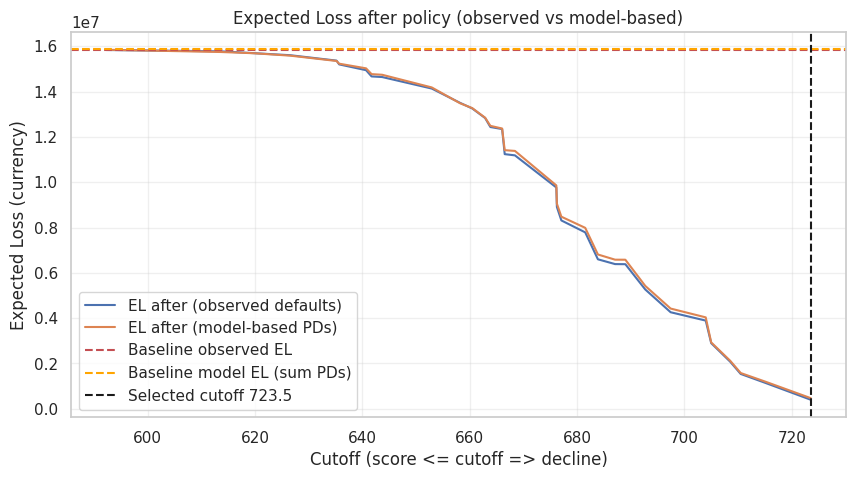

Saved selected cutoff summary to selected_cutoff_and_EL_summary.txt

Done. You now have observed- and model-based EL comparisons and KPI table saved.


In [ ]:
# ============================
# Compare Observed EL vs Model-based EL (using predicted PD p_test)
# ============================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, math, os
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
sns.set(style="whitegrid")

# ---------- USER INPUT (change if desired) ----------
LGD = 0.45                # Loss Given Default (fraction)
avg_EAD = 10000.0         # Average Exposure At Default per borrower
band_width = 25           # must match previous banding if used
target_recall = 0.70
min_precision = 0.20
selection_rule = "highest_cutoff_meeting_constraints"  # same options as before
# ----------------------------------------------------

# Helper: ensure p_test exists (calibrated probabilities)
if 'p_test' not in globals():
    # try common fallbacks
    try:
        p_test = woe_calibrated.predict_proba(Xw_test)[:,1]
        print("p_test created from woe_calibrated.")
    except Exception:
        try:
            p_test = final_pipeline.predict_proba(X_test_prep)[:,1]
            print("p_test created from final_pipeline.")
        except Exception:
            raise RuntimeError("p_test (predicted probabilities) not found. Run calibration or create p_test first.")

# ensure scores exist (mapping to scorecard)
if 'scores' not in globals():
    if 'offset' in globals() and 'factor' in globals():
        odds = np.maximum(p_test / (1 - p_test), 1e-9)
        scores = offset + factor * np.log(odds)
        print("scores computed from offset/factor and p_test.")
    else:
        raise RuntimeError("scores not found and cannot be computed (missing offset/factor).")

# Build df_scores if missing
if 'df_scores' not in globals():
    df_scores = pd.DataFrame({
        'score': np.asarray(scores),
        'pred_prob': np.asarray(p_test),
        'y': np.asarray(y_test) if hasattr(y_test, 'values')==False else y_test.values
    })
# create band column if missing (keeps same logic as before)
if 'band' not in df_scores.columns:
    min_s = math.floor(df_scores['score'].min() / band_width) * band_width
    max_s = math.ceil(df_scores['score'].max() / band_width) * band_width
    bins = np.arange(min_s, max_s + band_width, band_width)
    labels = [f"{int(b)}-{int(b+band_width-1)}" for b in bins[:-1]]
    df_scores['band'] = pd.cut(df_scores['score'], bins=bins, labels=labels, include_lowest=True, right=False)

scores_arr = np.asarray(df_scores['score'])
y_arr = np.asarray(df_scores['y'])
p_arr = np.asarray(df_scores['pred_prob'])

# Baseline portfolio metrics
total_accounts = len(df_scores)
total_defaults = int(y_arr.sum())
baseline_default_rate = total_defaults / total_accounts
baseline_EL_observed = total_defaults * avg_EAD * LGD
baseline_EL_model_based = p_arr.sum() * avg_EAD * LGD  # expected defaults = sum of predicted PDs

print(f"Baseline: accounts={total_accounts}, observed_defaults={total_defaults}, observed_EL={baseline_EL_observed:,.2f}, model_based_EL={baseline_EL_model_based:,.2f}")

# Build candidate cutoffs (same method as earlier)
percentiles = np.linspace(1,99,99)
candidates = np.unique(np.percentile(scores_arr, percentiles)).tolist()
candidates += list(np.unique(scores_arr)[::max(1, len(scores_arr)//300)])
candidates = np.unique(candidates)
candidates = np.sort(candidates)

# Evaluate per-candidate metrics including observed EL and model-based EL (for accepted set)
rows = []
for thr in candidates:
    y_pred = (scores_arr <= thr).astype(int)  # predicted default if score <= thr
    prec = precision_score(y_arr, y_pred, zero_division=0)
    rec = recall_score(y_arr, y_pred, zero_division=0)
    f1 = f1_score(y_arr, y_pred, zero_division=0)
    decline_rate = y_pred.mean()
    accept_mask = (scores_arr > thr)
    accepted_count = accept_mask.sum()
    accepted_defaults_observed = int(y_arr[accept_mask].sum())
    # Observed expected loss after policy = observed defaults among accepted * EAD * LGD
    EL_after_observed = accepted_defaults_observed * avg_EAD * LGD
    # Model-based expected defaults among accepted = sum of predicted PDs for accepted
    model_expected_defaults_accepted = p_arr[accept_mask].sum()
    EL_after_model = model_expected_defaults_accepted * avg_EAD * LGD

    rows.append({
        'cutoff': float(thr),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'decline_rate': float(decline_rate),
        'accepted_count': int(accepted_count),
        'accepted_defaults_observed': int(accepted_defaults_observed),
        'EL_after_observed': float(EL_after_observed),
        'model_expected_defaults_accepted': float(model_expected_defaults_accepted),
        'EL_after_model': float(EL_after_model)
    })

res_df = pd.DataFrame(rows).sort_values('cutoff').reset_index(drop=True)

# Selection logic (reuse selection_rule)
selected = None
if selection_rule == "max_f1":
    idx = res_df['f1'].idxmax(); selected = res_df.loc[idx]; reason = "max F1"
elif selection_rule == "best_precision_given_recall":
    cand = res_df[res_df['recall'] >= target_recall]
    if len(cand)>0: idx = cand['precision'].idxmax(); selected = res_df.loc[idx]; reason = "best precision with recall>=target"
    else: idx = res_df['f1'].idxmax(); selected = res_df.loc[idx]; reason = "fallback max F1"
else:  # highest_cutoff_meeting_constraints
    cand = res_df[(res_df['recall'] >= target_recall) & (res_df['precision'] >= min_precision)]
    if len(cand)>0:
        # pick highest cutoff (most conservative)
        thr_val = cand['cutoff'].max()
        selected = cand[cand['cutoff'] == thr_val].iloc[0]
        reason = "highest cutoff meeting both constraints"
    else:
        cand1 = res_df[res_df['recall'] >= target_recall]
        if len(cand1)>0: idx = cand1['precision'].idxmax(); selected = res_df.loc[idx]; reason = "no both; pick highest precision with recall>=target"
        else: idx = res_df['f1'].idxmax(); selected = res_df.loc[idx]; reason = "fallback max F1"

# Show selected cutoff and both ELs
thr = selected['cutoff']
print(f"\nSelected cutoff: {thr:.3f}  (rule: {selection_rule})  -- reason: {reason}")
# Confusion and metrics
y_pred_sel = (scores_arr <= thr).astype(int)
print("Precision, Recall, F1 on test for selected cutoff:")
print("Precision:", precision_score(y_arr, y_pred_sel, zero_division=0))
print("Recall:", recall_score(y_arr, y_pred_sel, zero_division=0))
print("F1:", f1_score(y_arr, y_pred_sel, zero_division=0))
cm = confusion_matrix(y_arr, y_pred_sel)
print("\nConfusion matrix:\n", cm)

# Portfolio EL comparison
accepted_mask = (scores_arr > thr)
accepted_count = accepted_mask.sum()
observed_defaults_accepted = int(y_arr[accepted_mask].sum())
model_expected_defaults_accepted = p_arr[accepted_mask].sum()
EL_after_observed = observed_defaults_accepted * avg_EAD * LGD
EL_after_model = model_expected_defaults_accepted * avg_EAD * LGD
delta_observed = baseline_EL_observed - EL_after_observed
delta_model = baseline_EL_model_based - EL_after_model

print(f"\nBaseline observed EL: {baseline_EL_observed:,.2f}")
print(f"Baseline model-based EL (sum PDs): {baseline_EL_model_based:,.2f}")
print(f"EL after policy (observed defaults): {EL_after_observed:,.2f} (reduction {delta_observed:,.2f})")
print(f"EL after policy (model PDs):          {EL_after_model:,.2f} (reduction {delta_model:,.2f})")

# Save res_df with both EL columns
out_cutoff_csv = "cutoff_el_comparison_results.csv"
res_df.to_csv(out_cutoff_csv, index=False)
print(f"\nSaved cutoff-by-cutoff EL comparison to: {out_cutoff_csv}")

# Build KPI table for representative cutoffs (deciles + selected)
rep_percentiles = list(range(10,100,10))
rep_cutoffs = sorted(set(list(np.unique(np.percentile(scores_arr, rep_percentiles))) + [thr]))
kpi_rows = []
for cut in rep_cutoffs:
    row = res_df[np.isclose(res_df['cutoff'], cut)].iloc[0]
    kpi_rows.append({
        'cutoff': row['cutoff'],
        'precision': row['precision'],
        'recall': row['recall'],
        'f1': row['f1'],
        'decline_rate': row['decline_rate'],
        'accepted_count': row['accepted_count'],
        'accepted_defaults_observed': row['accepted_defaults_observed'],
        'EL_after_observed': row['EL_after_observed'],
        'model_expected_defaults_accepted': row['model_expected_defaults_accepted'],
        'EL_after_model': row['EL_after_model']
    })
kpi_df = pd.DataFrame(kpi_rows).sort_values('cutoff', ascending=False).reset_index(drop=True)
kpi_csv = "kpi_table_observed_and_model_EL.csv"
kpi_df.to_csv(kpi_csv, index=False)
print(f"Saved KPI table to: {kpi_csv}")
display(kpi_df)

# Plot EL after policy: observed vs model-based
plt.figure(figsize=(10,5))
plt.plot(res_df['cutoff'], res_df['EL_after_observed'], label='EL after (observed defaults)')
plt.plot(res_df['cutoff'], res_df['EL_after_model'], label='EL after (model-based PDs)')
plt.axhline(baseline_EL_observed, color='r', linestyle='--', label='Baseline observed EL')
plt.axhline(baseline_EL_model_based, color='orange', linestyle='--', label='Baseline model EL (sum PDs)')
plt.axvline(thr, color='k', linestyle='--', label=f"Selected cutoff {thr:.1f}")
plt.xlabel("Cutoff (score <= cutoff => decline)")
plt.ylabel("Expected Loss (currency)")
plt.title("Expected Loss after policy (observed vs model-based)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Save selected cutoff details
with open("selected_cutoff_and_EL_summary.txt","w") as f:
    f.write(f"selected_cutoff={thr}\n")
    f.write(f"selection_rule={selection_rule}\n")
    f.write(f"observed_EL_before={baseline_EL_observed}\n")
    f.write(f"observed_EL_after={EL_after_observed}\n")
    f.write(f"model_EL_before={baseline_EL_model_based}\n")
    f.write(f"model_EL_after={EL_after_model}\n")
print("Saved selected cutoff summary to selected_cutoff_and_EL_summary.txt")

print("\nDone. You now have observed- and model-based EL comparisons and KPI table saved.")



📊 Suggested Cutoff Trade-offs (sorted by score cutoff):


,cutoff,precision,recall,f1,approval_rate_%,EL_reduction_obs_%,EL_reduction_model_%
0,723.545768,0.197,0.975,0.328,0.8,97.5,97.0
1,715.097750,0.190,0.928,0.316,2.4,92.8,92.4
2,710.491145,0.187,0.903,0.310,3.3,90.3,90.0
3,692.710498,0.157,0.668,0.254,14.8,66.8,65.8
4,689.000180,0.148,0.597,0.237,19.2,59.7,58.5
5,666.523136,0.106,0.291,0.156,45.2,29.1,28.0
6,643.688491,0.061,0.076,0.067,74.8,7.6,7.1
7,619.790913,0.027,0.010,0.014,92.7,1.0,1.1


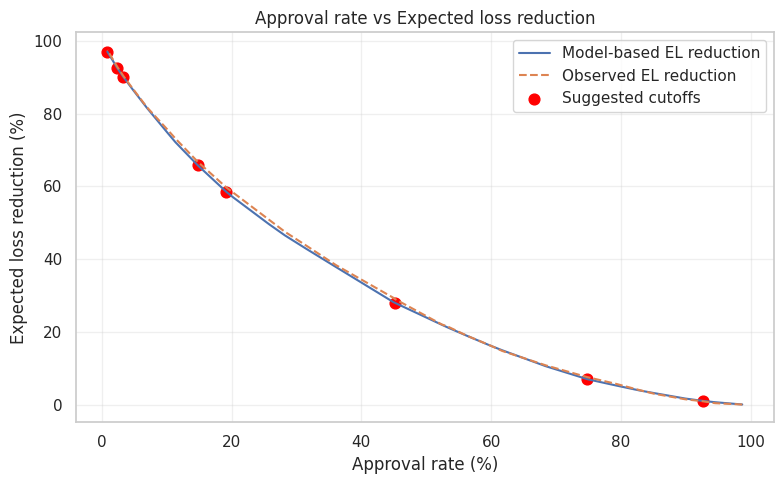

✅ Suggested cutoff trade-offs saved to: suggested_cutoff_tradeoffs.csv


In [ ]:
# ==========================
# 💡 Cutoff trade-off suggestions (approval vs loss reduction)
# ==========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Defensive checks
if 'res_df' not in globals():
    raise RuntimeError("res_df not found. Please run the previous EL comparison cell first.")

# Compute relative improvement metrics
df_trade = res_df.copy()
df_trade['EL_reduction_obs_%'] = 100 * (baseline_EL_observed - df_trade['EL_after_observed']) / baseline_EL_observed
df_trade['EL_reduction_model_%'] = 100 * (baseline_EL_model_based - df_trade['EL_after_model']) / baseline_EL_model_based
df_trade['approval_rate_%'] = 100 * (1 - df_trade['decline_rate'])

# Select top candidates
# Criterion: maximize F1 but also show different trade-offs
df_trade_sorted = df_trade.sort_values(by='f1', ascending=False)
top_candidates = pd.concat([
    df_trade_sorted.head(2),
    df_trade.loc[df_trade['recall'].between(target_recall - 0.05, target_recall + 0.05)].head(1),
    df_trade.loc[df_trade['precision'] >= min_precision].tail(1)
]).drop_duplicates().sort_values('cutoff', ascending=False)

# Pick 5 representative points: high, mid, low cutoff (approx 95th, median, 5th percentile)
percentile_points = np.percentile(df_trade['cutoff'], [95, 75, 50, 25, 5])
rep_points = []
for p in percentile_points:
    idx = (np.abs(df_trade['cutoff'] - p)).idxmin()
    rep_points.append(df_trade.loc[idx])
rep_df = pd.DataFrame(rep_points)

# Merge all and drop duplicates
suggested = pd.concat([top_candidates, rep_df]).drop_duplicates().sort_values('cutoff', ascending=False).reset_index(drop=True)

# Format and display summary table
cols = ['cutoff','precision','recall','f1','approval_rate_%','EL_reduction_obs_%','EL_reduction_model_%']
print("\n📊 Suggested Cutoff Trade-offs (sorted by score cutoff):")
display(suggested[cols].style.background_gradient(cmap='Blues', axis=None).format({
    'precision':"{:.3f}",
    'recall':"{:.3f}",
    'f1':"{:.3f}",
    'approval_rate_%':"{:.1f}",
    'EL_reduction_obs_%':"{:.1f}",
    'EL_reduction_model_%':"{:.1f}"
}))

# Plot trade-off curve (Approval rate vs Expected Loss Reduction)
plt.figure(figsize=(8,5))
plt.plot(df_trade['approval_rate_%'], df_trade['EL_reduction_model_%'], label='Model-based EL reduction')
plt.plot(df_trade['approval_rate_%'], df_trade['EL_reduction_obs_%'], linestyle='--', label='Observed EL reduction')
plt.scatter(suggested['approval_rate_%'], suggested['EL_reduction_model_%'], color='red', s=60, label='Suggested cutoffs')
plt.xlabel("Approval rate (%)")
plt.ylabel("Expected loss reduction (%)")
plt.title("Approval rate vs Expected loss reduction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save to CSV
suggested_csv = "suggested_cutoff_tradeoffs.csv"
suggested[cols].to_csv(suggested_csv, index=False)
print(f"✅ Suggested cutoff trade-offs saved to: {suggested_csv}")


In [ ]:
!pip install streamlit plotly pandas scikit-learn pyngrok==5.1.0
!npm install -g localtunnel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyngrok: filename=pyngrok-5.1.0-py3-none-any.whl size=18987 sha256=435d6a0f90df53ad87e166fb7ec39c50bfcfcde90ca54a33a54599c33a7d5f46
  Stored in directory: /root/.cache/pip/wheels/30/58/2e/9da9e0c4b026f37b005248a3f2045f0e4f69e365f5addeccf7
Successfully built pyngrok
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 6s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [ ]:
# in notebook cell
!pip install streamlit plotly pandas scikit-learn
!npm install -g localtunnel
!nohup streamlit run app.py --server.port 8501 &>/content/streamlit.log &
!lt --port 8501 --subdomain myuniquesubdomain


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 4s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸your url is: https://myuniquesubdomain.loca.lt
/tools/node/lib/node_modules/localtunnel/bin/lt.js:81
    throw err;
    ^

Error: connection refused: localtunnel.me:6209 (check your firewall settings)
    at Socket.<anonymous> (/tools/node/lib/node_modules/localtunnel/lib/TunnelCluster.js:52:11)
    at Socket.emit (node:events:524:28)
    at emitErrorNT (node:internal/streams/destroy:169:8)
    at emitErrorCloseNT (node:internal/streams/destroy:128:3)
    at process.processTicksAndRejections (node:internal/process/task_queues:82:21)

Node.js v20.19.0


In [ ]:
# ---------- Bottom: detailed cutoff explorer (DEFENSIVE VERSION) ----------
st.header("Cutoff Explorer")

# Helper: compute a safe default selected_cutoff from res_df if possible
def compute_default_cutoff(res_df_local):
    try:
        # prefer the highest cutoff meeting both constraints if available
        cand = res_df_local[(res_df_local['recall'] >= target_recall) & (res_df_local['precision'] >= min_precision)]
        if len(cand) > 0:
            return float(cand['cutoff'].max())
        # fallback: cutoff with max F1
        return float(res_df_local.loc[res_df_local['f1'].idxmax(), 'cutoff'])
    except Exception:
        # last resort: median of available cutoffs
        try:
            return float(np.median(res_df_local['cutoff'].values))
        except Exception:
            return None

# If we don't have per-account data, show helpful message and, if possible, show static KPI file info
if show_static_only or df_scores is None:
    st.info("Per-account score data is not available. To enable interactive cutoff exploration you need `score_to_risk_table.csv` (per-account rows with columns 'score','pred_prob','y').")
    if res_df is not None:
        st.subheader("Available cutoff-level summary (static)")
        # show a small static table
        st.dataframe(res_df.sort_values('cutoff', ascending=False).head(10))
    else:
        st.info("No cutoff summary data (res_df) available either.")
else:
    # df_scores exists but might be missing columns. Check columns first.
    required_cols = {'score','pred_prob','y'}
    missing_cols = required_cols - set(df_scores.columns)
    if missing_cols:
        st.error(f"The per-account data is present but missing required columns: {missing_cols}. Please ensure the CSV has columns 'score','pred_prob','y'.")
        st.write("Found columns:", list(df_scores.columns)[:50])
    else:
        # Safe: compute selected_cutoff if not already defined
        if 'selected_cutoff' not in globals():
            if res_df is not None:
                try:
                    selected_cutoff = compute_default_cutoff(res_df)
                except Exception:
                    selected_cutoff = float(df_scores['score'].median())
            else:
                selected_cutoff = float(df_scores['score'].median())

        # final fallback
        if selected_cutoff is None or np.isnan(selected_cutoff):
            selected_cutoff = float(df_scores['score'].median())

        # Slider and metrics
        cutoff_slider = st.slider("Pick a cutoff (score <= cutoff => decline)",
                                  float(df_scores['score'].min()), float(df_scores['score'].max()),
                                  float(selected_cutoff), step=0.1)

        mask_decline = df_scores['score'].values <= cutoff_slider
        y_true = np.asarray(df_scores['y'].values)
        y_pred = mask_decline.astype(int)

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        decline_rate = float(y_pred.mean())

        # Show key metrics
        col_a, col_b, col_c, col_d = st.columns(4)
        col_a.metric("Precision", f"{prec:.3f}")
        col_b.metric("Recall", f"{rec:.3f}")
        col_c.metric("F1", f"{f1:.3f}")
        col_d.metric("Decline rate", f"{100*decline_rate:.2f}%")

        # Confusion matrix display
        st.subheader("Confusion matrix (rows=actual, cols=predicted)")
        cm = confusion_matrix(y_true, y_pred)
        st.write(cm)

        # Per-band summary and plotting
        try:
            band_summary = df_scores.groupby('band').agg(
                count=('y','size'),
                defaults=('y','sum'),
                avg_prob=('pred_prob','mean'),
                avg_score=('score','mean')
            ).reset_index()
            st.subheader("Score band summary (top bands)")
            st.dataframe(band_summary.sort_values('band', ascending=False).head(20))
        except Exception as e:
            st.warning("Could not compute band summary: " + str(e))

        # Export current policy
        if st.button("Export selected cutoff & policy summary"):
            summary = {
                'cutoff': float(cutoff_slider),
                'precision': float(prec),
                'recall': float(rec),
                'f1': float(f1),
                'decline_rate': float(decline_rate),
                'LGD': float(LGD),
                'avg_EAD': float(avg_EAD)
            }
            out_name = f"policy_summary_cutoff_{int(round(cutoff_slider))}.csv"
            pd.DataFrame([summary]).to_csv(out_name, index=False)
            st.success(f"Saved policy summary to {out_name}")

# final note/footer
st.markdown("---")
st.markdown("If you need help exporting per-account score data from the notebook, run the 'score -> risk table' cell (it saves `score_to_risk_table.csv`).")


2025-10-12 23:11:17.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.669 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-12 23:11:17.685 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()